# 📊 Statistiques Descriptives — SP500 | GOLD | BRENT | EURUSD
**Données M5 récupérées via MetaTrader5 (Admirals)**

Ce notebook réalise une analyse statistique complète des quatre actifs :
1. Chargement et audit des données
2. Statistiques descriptives comparées
3. Analyse des distributions et tests de normalité (Jarque-Bera)
4. Tests de stationnarité (ADF — implémenté en numpy)
5. Analyse des autocorrélations (ACF/PACF, Ljung-Box)
6. Analyse de la volatilité et des queues de distribution
7. Corrélations statiques et dynamiques
8. Risk metrics (VaR, CVaR)

---
## 0. Imports & Configuration
> **Dépendances uniquement** : `pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy` — pas de statsmodels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

COLORS = {
    'SP500':  '#2196F3',
    'GOLD':   '#FFC107',
    'BRENT':  '#4CAF50',
    'EURUSD': '#E91E63'
}

print('✅ Imports OK')

✅ Imports OK


---
## 1. Fonctions statistiques (implémentées en numpy)
Ces fonctions remplacent statsmodels et sont transparentes sur les formules utilisées.

In [2]:
# ── ACF manuelle ──────────────────────────────────────────────────────────────
def compute_acf(series, nlags=40):
    """Autocorrélation jusqu'au lag nlags."""
    s = np.asarray(series.dropna()) - np.mean(series.dropna())
    n = len(s)
    var = np.var(s)
    acf_vals = [1.0]
    for k in range(1, nlags + 1):
        cov_k = np.sum(s[:n-k] * s[k:]) / n
        acf_vals.append(cov_k / var)
    return np.array(acf_vals)


# ── Test de Ljung-Box ─────────────────────────────────────────────────────────
def ljung_box(series, lags):
    """Retourne (statistique Q, p-value) pour le lag donné.
    H0 : pas d'autocorrélation jusqu'au lag 'lags'.
    """
    s = np.asarray(series.dropna())
    n = len(s)
    acf_v = compute_acf(series, nlags=lags)
    q = n * (n + 2) * np.sum(acf_v[1:lags+1]**2 / (n - np.arange(1, lags+1)))
    p = 1 - stats.chi2.cdf(q, df=lags)
    return q, p


# ── Test de Jarque-Bera ───────────────────────────────────────────────────────
def jarque_bera(series):
    """Retourne (statistique JB, p-value).
    H0 : la distribution est normale (skewness=0, kurtosis excess=0).
    """
    s = np.asarray(series.dropna())
    n = len(s)
    skew = stats.skew(s)
    kurt = stats.kurtosis(s)  # excess kurtosis
    jb = n / 6 * (skew**2 + kurt**2 / 4)
    p  = 1 - stats.chi2.cdf(jb, df=2)
    return jb, p


# ── ADF simplifié ─────────────────────────────────────────────────────────────
def adf_test(series):
    """
    Augmented Dickey-Fuller simplifié (numpy).
    H0 : la série possède une racine unitaire (non-stationnaire).
    Retourne : (adf_stat, p_approx, valeurs_critiques)
    """
    s = np.asarray(series.dropna(), dtype=float)
    # Différence première et lag
    ds    = np.diff(s)
    y_lag = s[:-1]
    # Régression OLS : ds = alpha + beta*y_lag + epsilon
    X = np.column_stack([np.ones(len(y_lag)), y_lag])
    b, _, _, _ = np.linalg.lstsq(X, ds, rcond=None)
    resid = ds - X @ b
    s2    = np.sum(resid**2) / (len(ds) - 2)
    cov   = s2 * np.linalg.pinv(X.T @ X)
    se    = np.sqrt(np.diag(cov))
    adf_stat = b[1] / se[1]
    # Valeurs critiques MacKinnon (approximées)
    cv = {'1%': -3.43, '5%': -2.86, '10%': -2.57}
    if   adf_stat < cv['1%']:  p = 0.01
    elif adf_stat < cv['5%']:  p = 0.05
    elif adf_stat < cv['10%']: p = 0.10
    else:                      p = 0.99
    return adf_stat, p, cv


print('✅ Fonctions statistiques chargées')

✅ Fonctions statistiques chargées


---
## 2. Chargement des données

In [3]:
DATA_DIR = Path('../SCR/data')

sp500  = pd.read_csv(DATA_DIR / 'sp500_m5.csv',  index_col='time', parse_dates=True)
gold   = pd.read_csv(DATA_DIR / 'or_m5.csv',     index_col='time', parse_dates=True)
brent  = pd.read_csv(DATA_DIR / 'brent_m5.csv',  index_col='time', parse_dates=True)
eurusd = pd.read_csv(DATA_DIR / 'eurusd_m5.csv', index_col='time', parse_dates=True)

datasets = {'SP500': sp500, 'GOLD': gold, 'BRENT': brent, 'EURUSD': eurusd}

print('✅ Données chargées')
sp500.head(5)

✅ Données chargées


,open,high,low,close,tick_volume
time,,,,,
2024-11-14 15:20:00+00:00,5995.33,5995.71,5994.22,5995.50,105
2024-11-14 15:25:00+00:00,5995.74,5996.00,5994.49,5995.73,100
2024-11-14 15:30:00+00:00,5995.48,5995.85,5985.72,5986.59,494
2024-11-14 15:35:00+00:00,5986.71,5988.46,5981.72,5985.08,404
2024-11-14 15:40:00+00:00,5985.45,5992.08,5985.44,5989.95,313


---
## 3. Audit de la qualité des données

In [4]:
# ── 3.1 Résumé général ────────────────────────────────────────────────────────
audit_rows = []
for name, df in datasets.items():
    audit_rows.append({
        'Actif':       name,
        'Bougies':     len(df),
        'Début':       df.index.min().strftime('%Y-%m-%d'),
        'Fin':         df.index.max().strftime('%Y-%m-%d'),
        'NaN (close)': df['close'].isna().sum(),
        'Doublons':    df.index.duplicated().sum(),
    })
display(pd.DataFrame(audit_rows).set_index('Actif'))

,Bougies,Début,Fin,NaN (close),Doublons
Actif,,,,,
SP500,99999,2024-11-14,2026-04-17,0,0
GOLD,99999,2024-11-15,2026-04-17,0,0
BRENT,99999,2024-10-08,2026-04-17,0,0
EURUSD,99999,2024-12-11,2026-04-17,0,0


In [5]:
# ── 3.2 Gaps temporels (> 10 min, hors week-end) ──────────────────────────────
print('=== Gaps temporels > 10 min (hors week-end) ===')
for name, df in datasets.items():
    delta = df.index.to_series().diff().dt.total_seconds() / 60
    gaps  = delta[(delta > 10) & (delta < 2000)]
    print(f'  {name:8s}: {len(gaps):4d} gaps | max = {gaps.max():.0f} min')

=== Gaps temporels > 10 min (hors week-end) ===
  SP500   :  297 gaps | max = 1730 min
  GOLD    :  294 gaps | max = 1700 min
  BRENT   :  321 gaps | max = 1835 min
  EURUSD  :    4 gaps | max = 1510 min


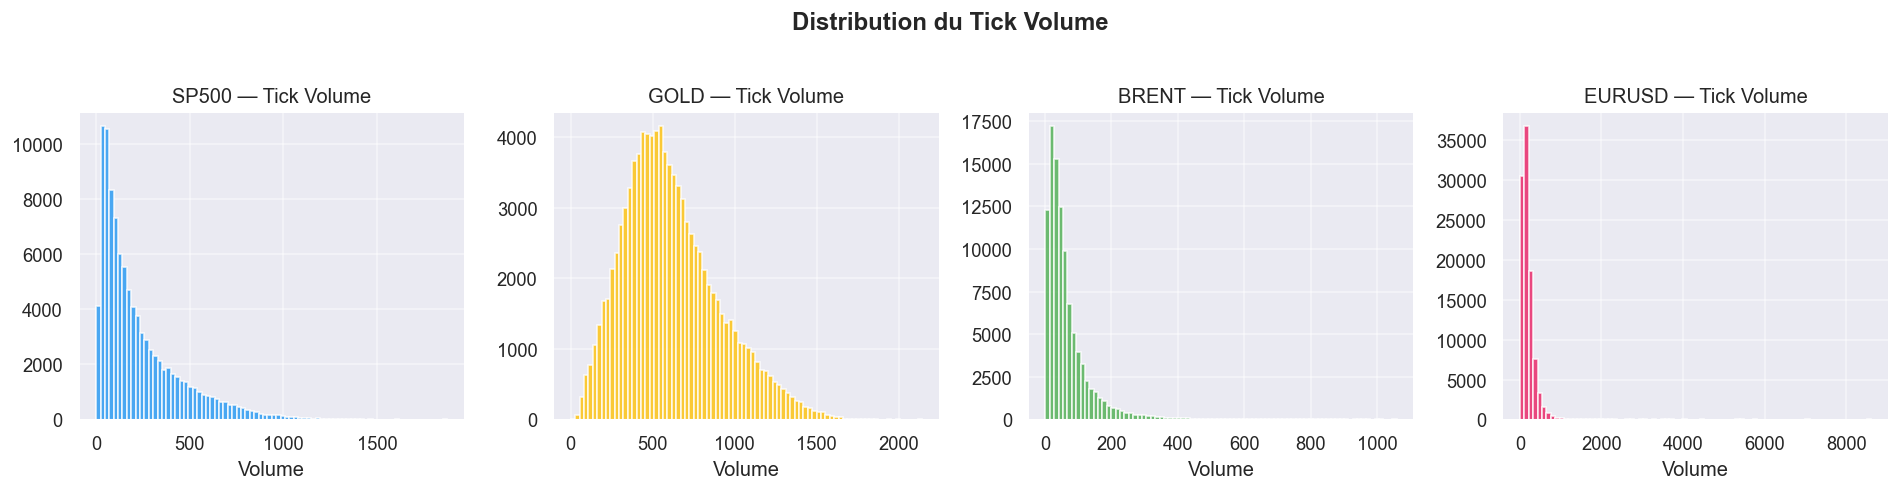

In [6]:
# ── 3.3 Distribution du tick_volume ───────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, df) in zip(axes, datasets.items()):
    ax.hist(df['tick_volume'], bins=80, color=COLORS[name], alpha=0.8, edgecolor='white')
    ax.set_title(f'{name} — Tick Volume')
    ax.set_xlabel('Volume')
plt.suptitle('Distribution du Tick Volume', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Prix de clôture — Vue d'ensemble

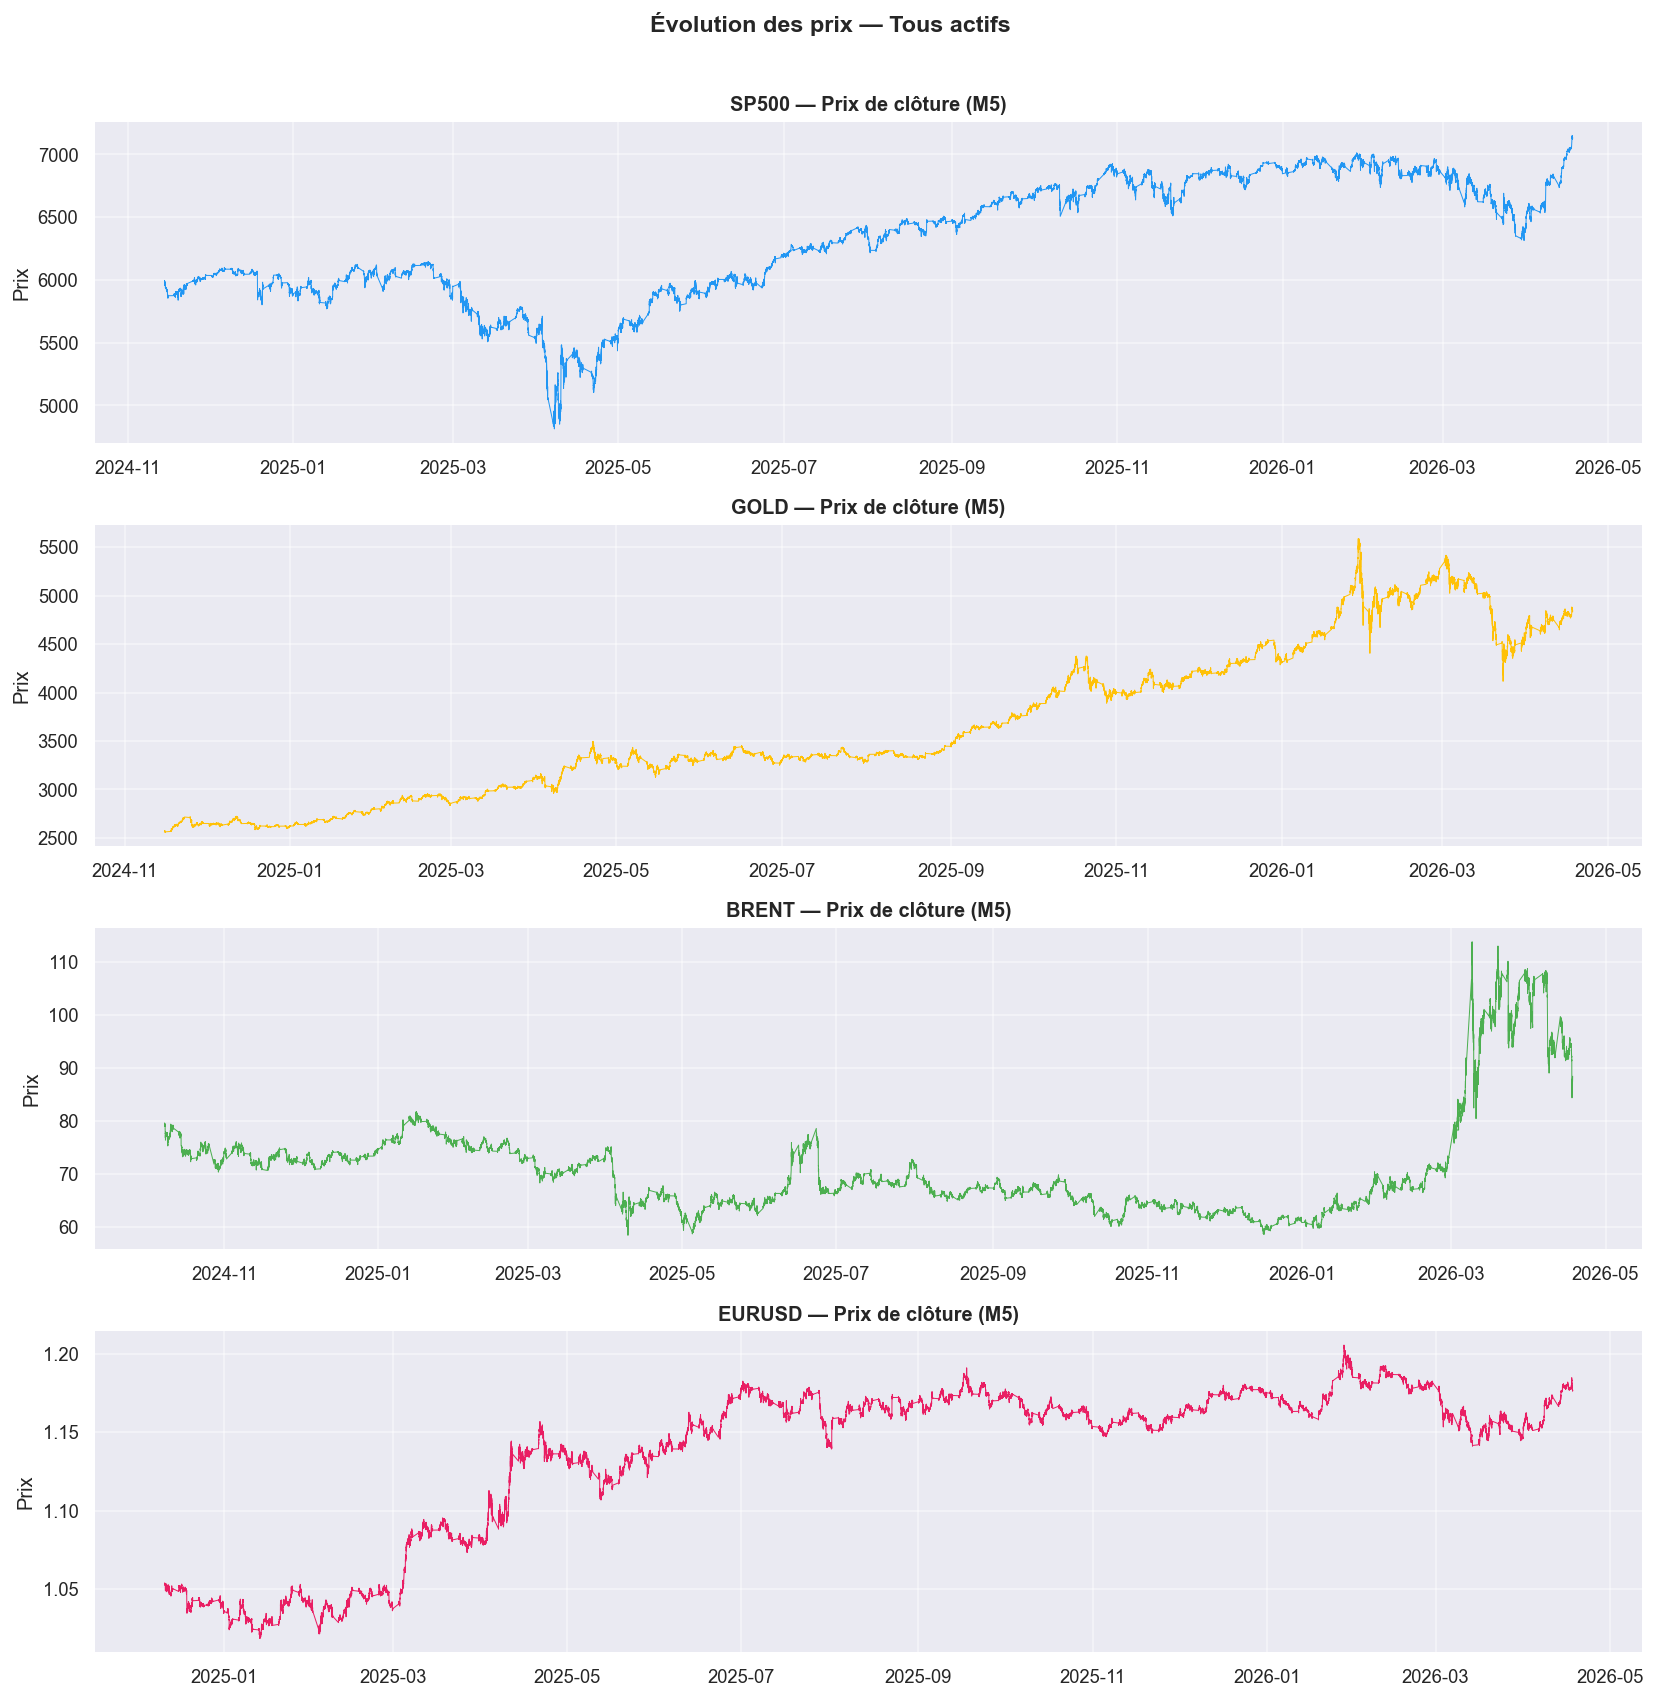

In [7]:
# ── 4.1 Séries de prix ────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, (name, df) in zip(axes, datasets.items()):
    ax.plot(df['close'], lw=0.6, color=COLORS[name])
    ax.set_title(f'{name} — Prix de clôture (M5)', fontweight='bold')
    ax.set_ylabel('Prix')
plt.suptitle('Évolution des prix — Tous actifs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

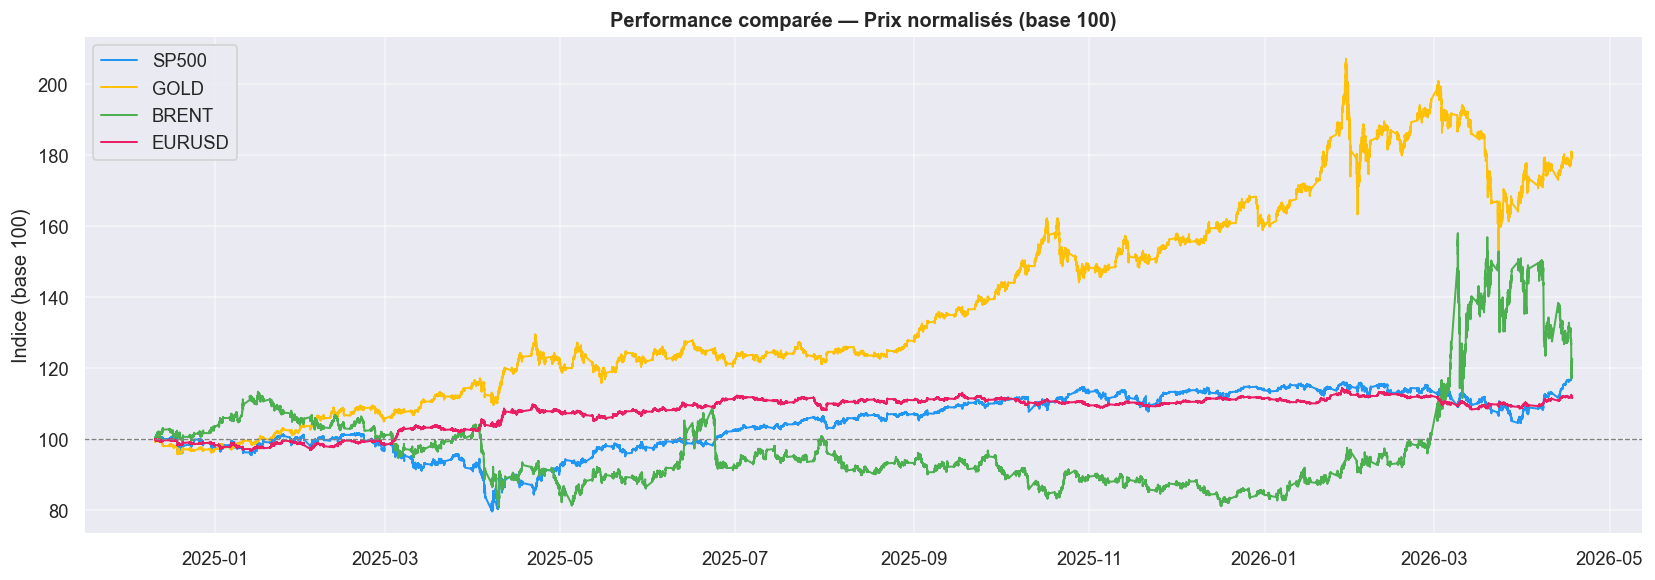

In [8]:
# ── 4.2 Performance normalisée base 100 ───────────────────────────────────────
df_close  = pd.DataFrame({name: df['close'] for name, df in datasets.items()}).dropna()
prix_norm = df_close / df_close.iloc[0] * 100

plt.figure(figsize=(14, 5))
for name in prix_norm.columns:
    plt.plot(prix_norm[name], lw=1.2, label=name, color=COLORS[name])
plt.axhline(100, color='gray', lw=0.8, linestyle='--')
plt.title('Performance comparée — Prix normalisés (base 100)', fontweight='bold')
plt.ylabel('Indice (base 100)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Log Returns — Calcul et statistiques descriptives

In [9]:
# ── 5.1 Calcul des log returns ────────────────────────────────────────────────
for name, df in datasets.items():
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

df_returns = pd.DataFrame(
    {name: df['log_return'] for name, df in datasets.items()}
).dropna()

print(f'✅ Log returns calculés. Shape : {df_returns.shape}')

✅ Log returns calculés. Shape : (87990, 4)


In [10]:
# ── 5.2 Statistiques descriptives comparées ───────────────────────────────────
# 78 bougies M5 par séance * 252 séances/an
BOUGIES_PAR_AN = 252 * 78

rows = []
for name in df_returns.columns:
    r = df_returns[name].dropna()
    rows.append({
        'Actif':         name,
        'Moyenne':       round(r.mean(), 7),
        'Médiane':       round(r.median(), 7),
        'Std':           round(r.std(), 6),
        'Min':           round(r.min(), 5),
        'Max':           round(r.max(), 5),
        'Skewness':      round(r.skew(), 4),
        'Kurtosis exc.': round(r.kurtosis(), 4),
        'Vol. Ann. (%)': round(r.std() * np.sqrt(BOUGIES_PAR_AN) * 100, 2),
    })
display(pd.DataFrame(rows).set_index('Actif'))

,Moyenne,Médiane,Std,Min,Max,Skewness,Kurtosis exc.,Vol. Ann. (%)
Actif,,,,,,,,
SP500,0.000002,0.000000,0.000716,-0.04268,0.03901,0.1884,385.5714,10.03
GOLD,0.000004,0.000011,0.000910,-0.02124,0.02847,-0.8237,48.4013,12.75
BRENT,0.000002,0.000000,0.001789,-0.14201,0.16062,2.5342,1447.1200,25.08
EURUSD,0.000001,0.000000,0.000307,-0.00787,0.01003,0.4252,51.7327,4.31


---
## 6. Distribution des rendements & Tests de normalité

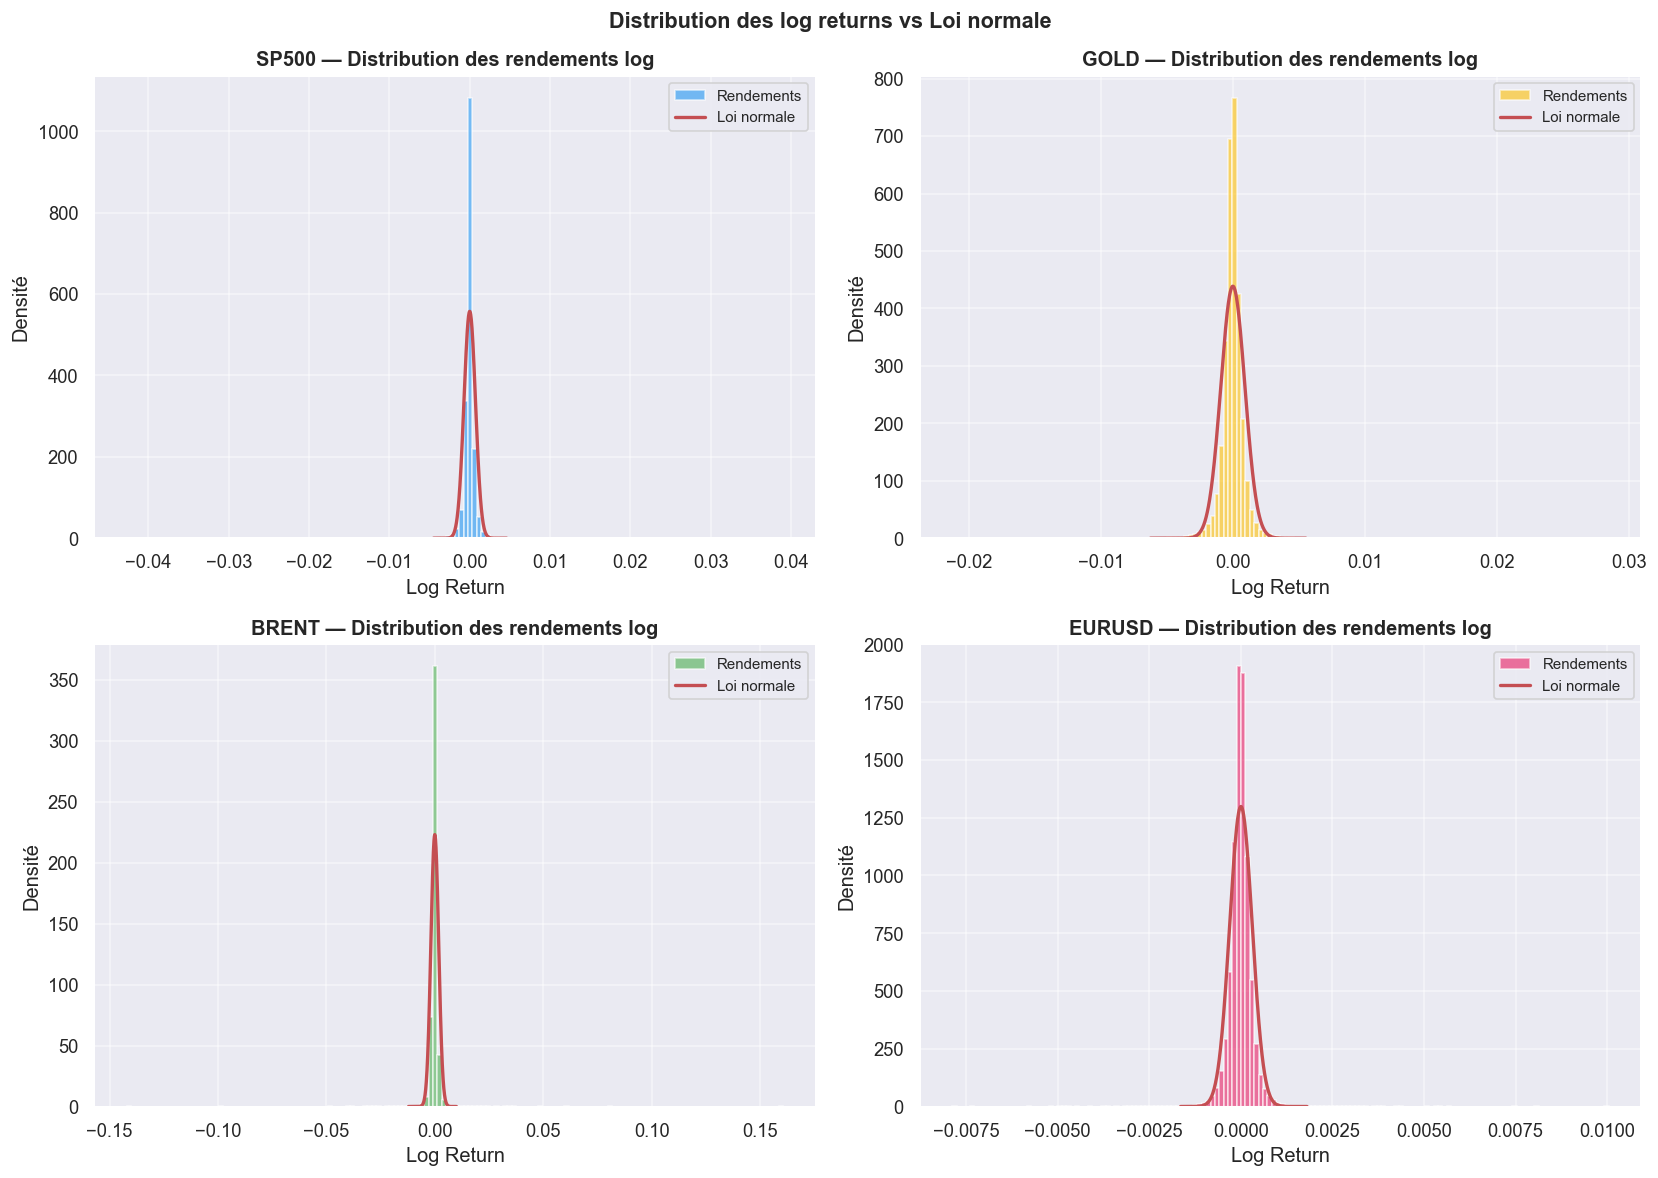

In [11]:
# ── 6.1 Histogrammes vs loi normale ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    r = df_returns[name].dropna()
    ax.hist(r, bins=150, density=True, alpha=0.6, color=COLORS[name], label='Rendements')
    x = np.linspace(r.quantile(0.001), r.quantile(0.999), 400)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'r-', lw=2, label='Loi normale')
    ax.set_title(f'{name} — Distribution des rendements log', fontweight='bold')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)
plt.suptitle('Distribution des log returns vs Loi normale', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

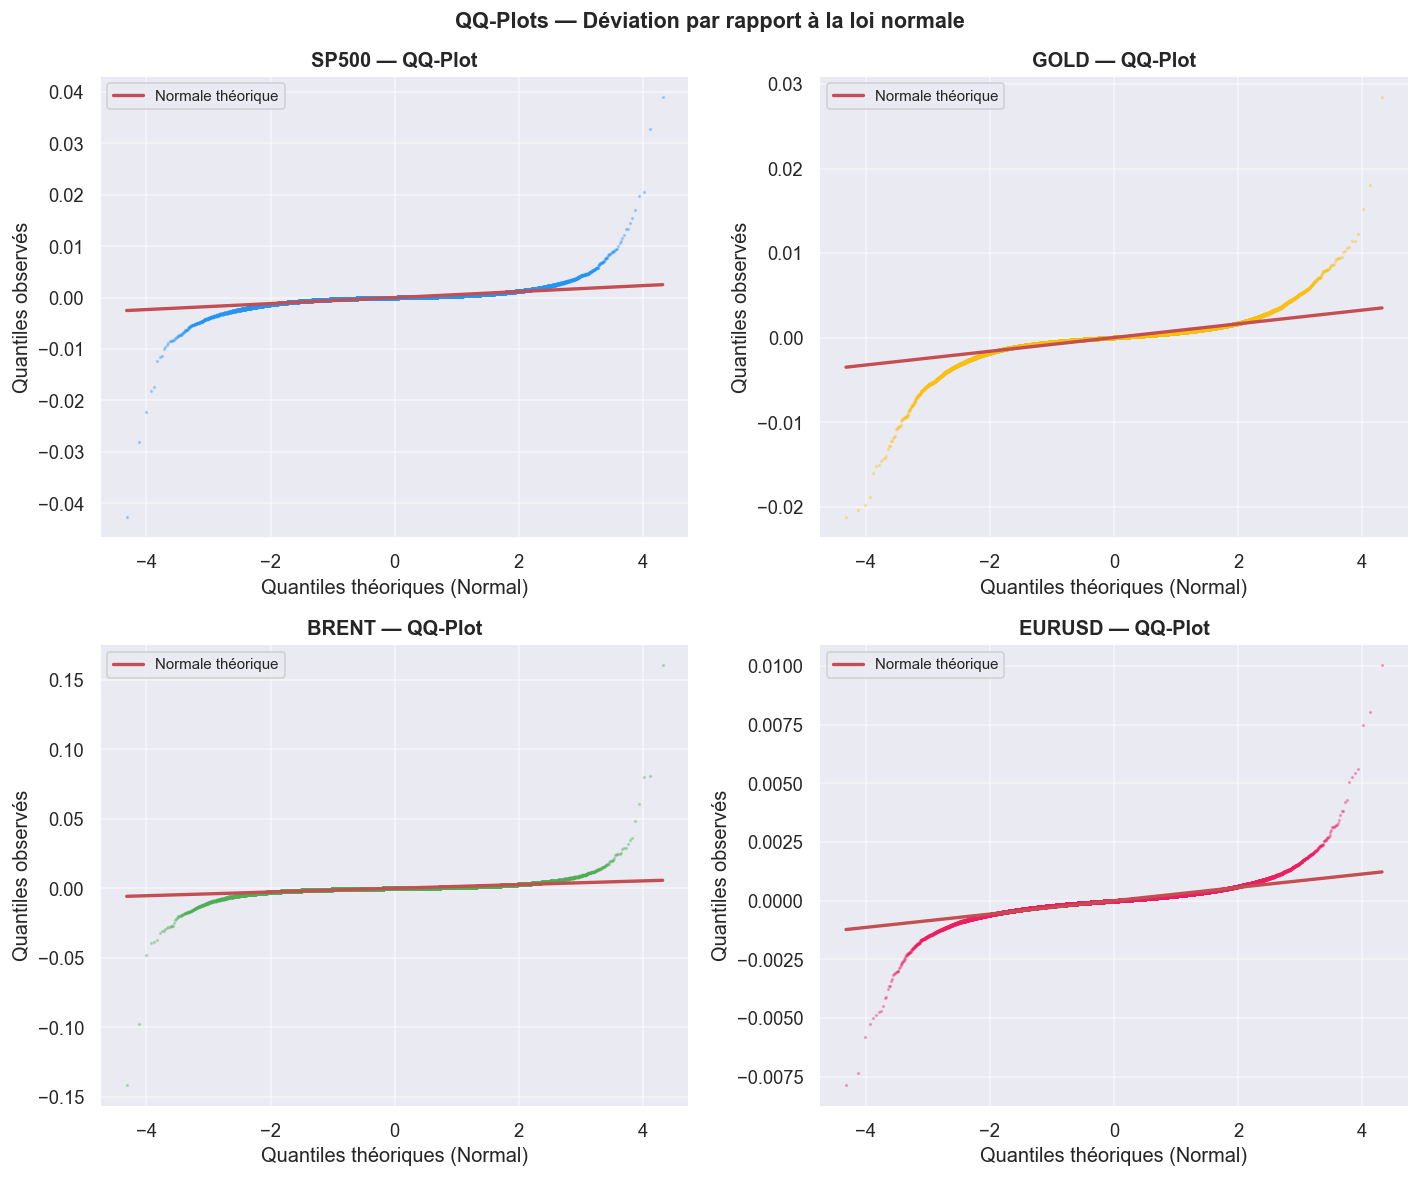

In [12]:
# ── 6.2 QQ-Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    r = df_returns[name].dropna()
    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    ax.scatter(osm, osr, s=1, alpha=0.3, color=COLORS[name])
    ax.plot(osm, slope * np.array(osm) + intercept, 'r-', lw=2, label='Normale théorique')
    ax.set_title(f'{name} — QQ-Plot', fontweight='bold')
    ax.set_xlabel('Quantiles théoriques (Normal)')
    ax.set_ylabel('Quantiles observés')
    ax.legend(fontsize=9)
plt.suptitle('QQ-Plots — Déviation par rapport à la loi normale', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# ── 6.3 Test de Jarque-Bera ───────────────────────────────────────────────────
print('=== Test de Jarque-Bera (H0 : normalité) ===')
print(f"{'Actif':8s} {'Stat JB':>14s} {'p-value':>10s} {'Décision':>22s}")
print('-' * 58)
for name in df_returns.columns:
    jb, p = jarque_bera(df_returns[name])
    dec   = '❌ Rejette normalité' if p < 0.05 else '✅ Ne rejette pas'
    print(f'{name:8s} {jb:>14.2f} {p:>10.4f} {dec:>22s}')

=== Test de Jarque-Bera (H0 : normalité) ===
Actif           Stat JB    p-value               Décision
----------------------------------------------------------
SP500      544982681.27     0.0000    ❌ Rejette normalité
GOLD         8597836.40     0.0000    ❌ Rejette normalité
BRENT     7676921147.72     0.0000    ❌ Rejette normalité
EURUSD       9813400.98     0.0000    ❌ Rejette normalité


---
## 7. Tests de Stationnarité (ADF)

In [14]:
# ── 7.1 ADF sur prix et sur log returns ───────────────────────────────────────
print('=== Test ADF — H0 : racine unitaire (non-stationnaire) ===')
print(f"{'Actif':8s} {'Série':12s} {'ADF stat':>10s} {'p-value':>10s} {'Val. crit 5%':>13s} {'Stationnaire':>14s}")
print('-' * 72)
for name, df in datasets.items():
    for label, series in [('Prix close', df['close']), ('Log return', df['log_return'])]:
        stat, p, cv = adf_test(series)
        dec = '✅ Oui' if p < 0.05 else '❌ Non'
        print(f"{name:8s} {label:12s} {stat:>10.4f} {p:>10.4f} {cv['5%']:>13.2f} {dec:>14s}")

=== Test ADF — H0 : racine unitaire (non-stationnaire) ===
Actif    Série          ADF stat    p-value  Val. crit 5%   Stationnaire
------------------------------------------------------------------------
SP500    Prix close      -0.9057     0.9900         -2.86          ❌ Non
SP500    Log return    -315.7103     0.0100         -2.86          ✅ Oui
GOLD     Prix close      -0.7095     0.9900         -2.86          ❌ Non
GOLD     Log return    -314.3515     0.0100         -2.86          ✅ Oui
BRENT    Prix close      -2.1939     0.9900         -2.86          ❌ Non
BRENT    Log return    -322.4311     0.0100         -2.86          ✅ Oui
EURUSD   Prix close      -1.5793     0.9900         -2.86          ❌ Non
EURUSD   Log return    -322.6345     0.0100         -2.86          ✅ Oui


---
## 8. Autocorrélations (ACF / Ljung-Box)

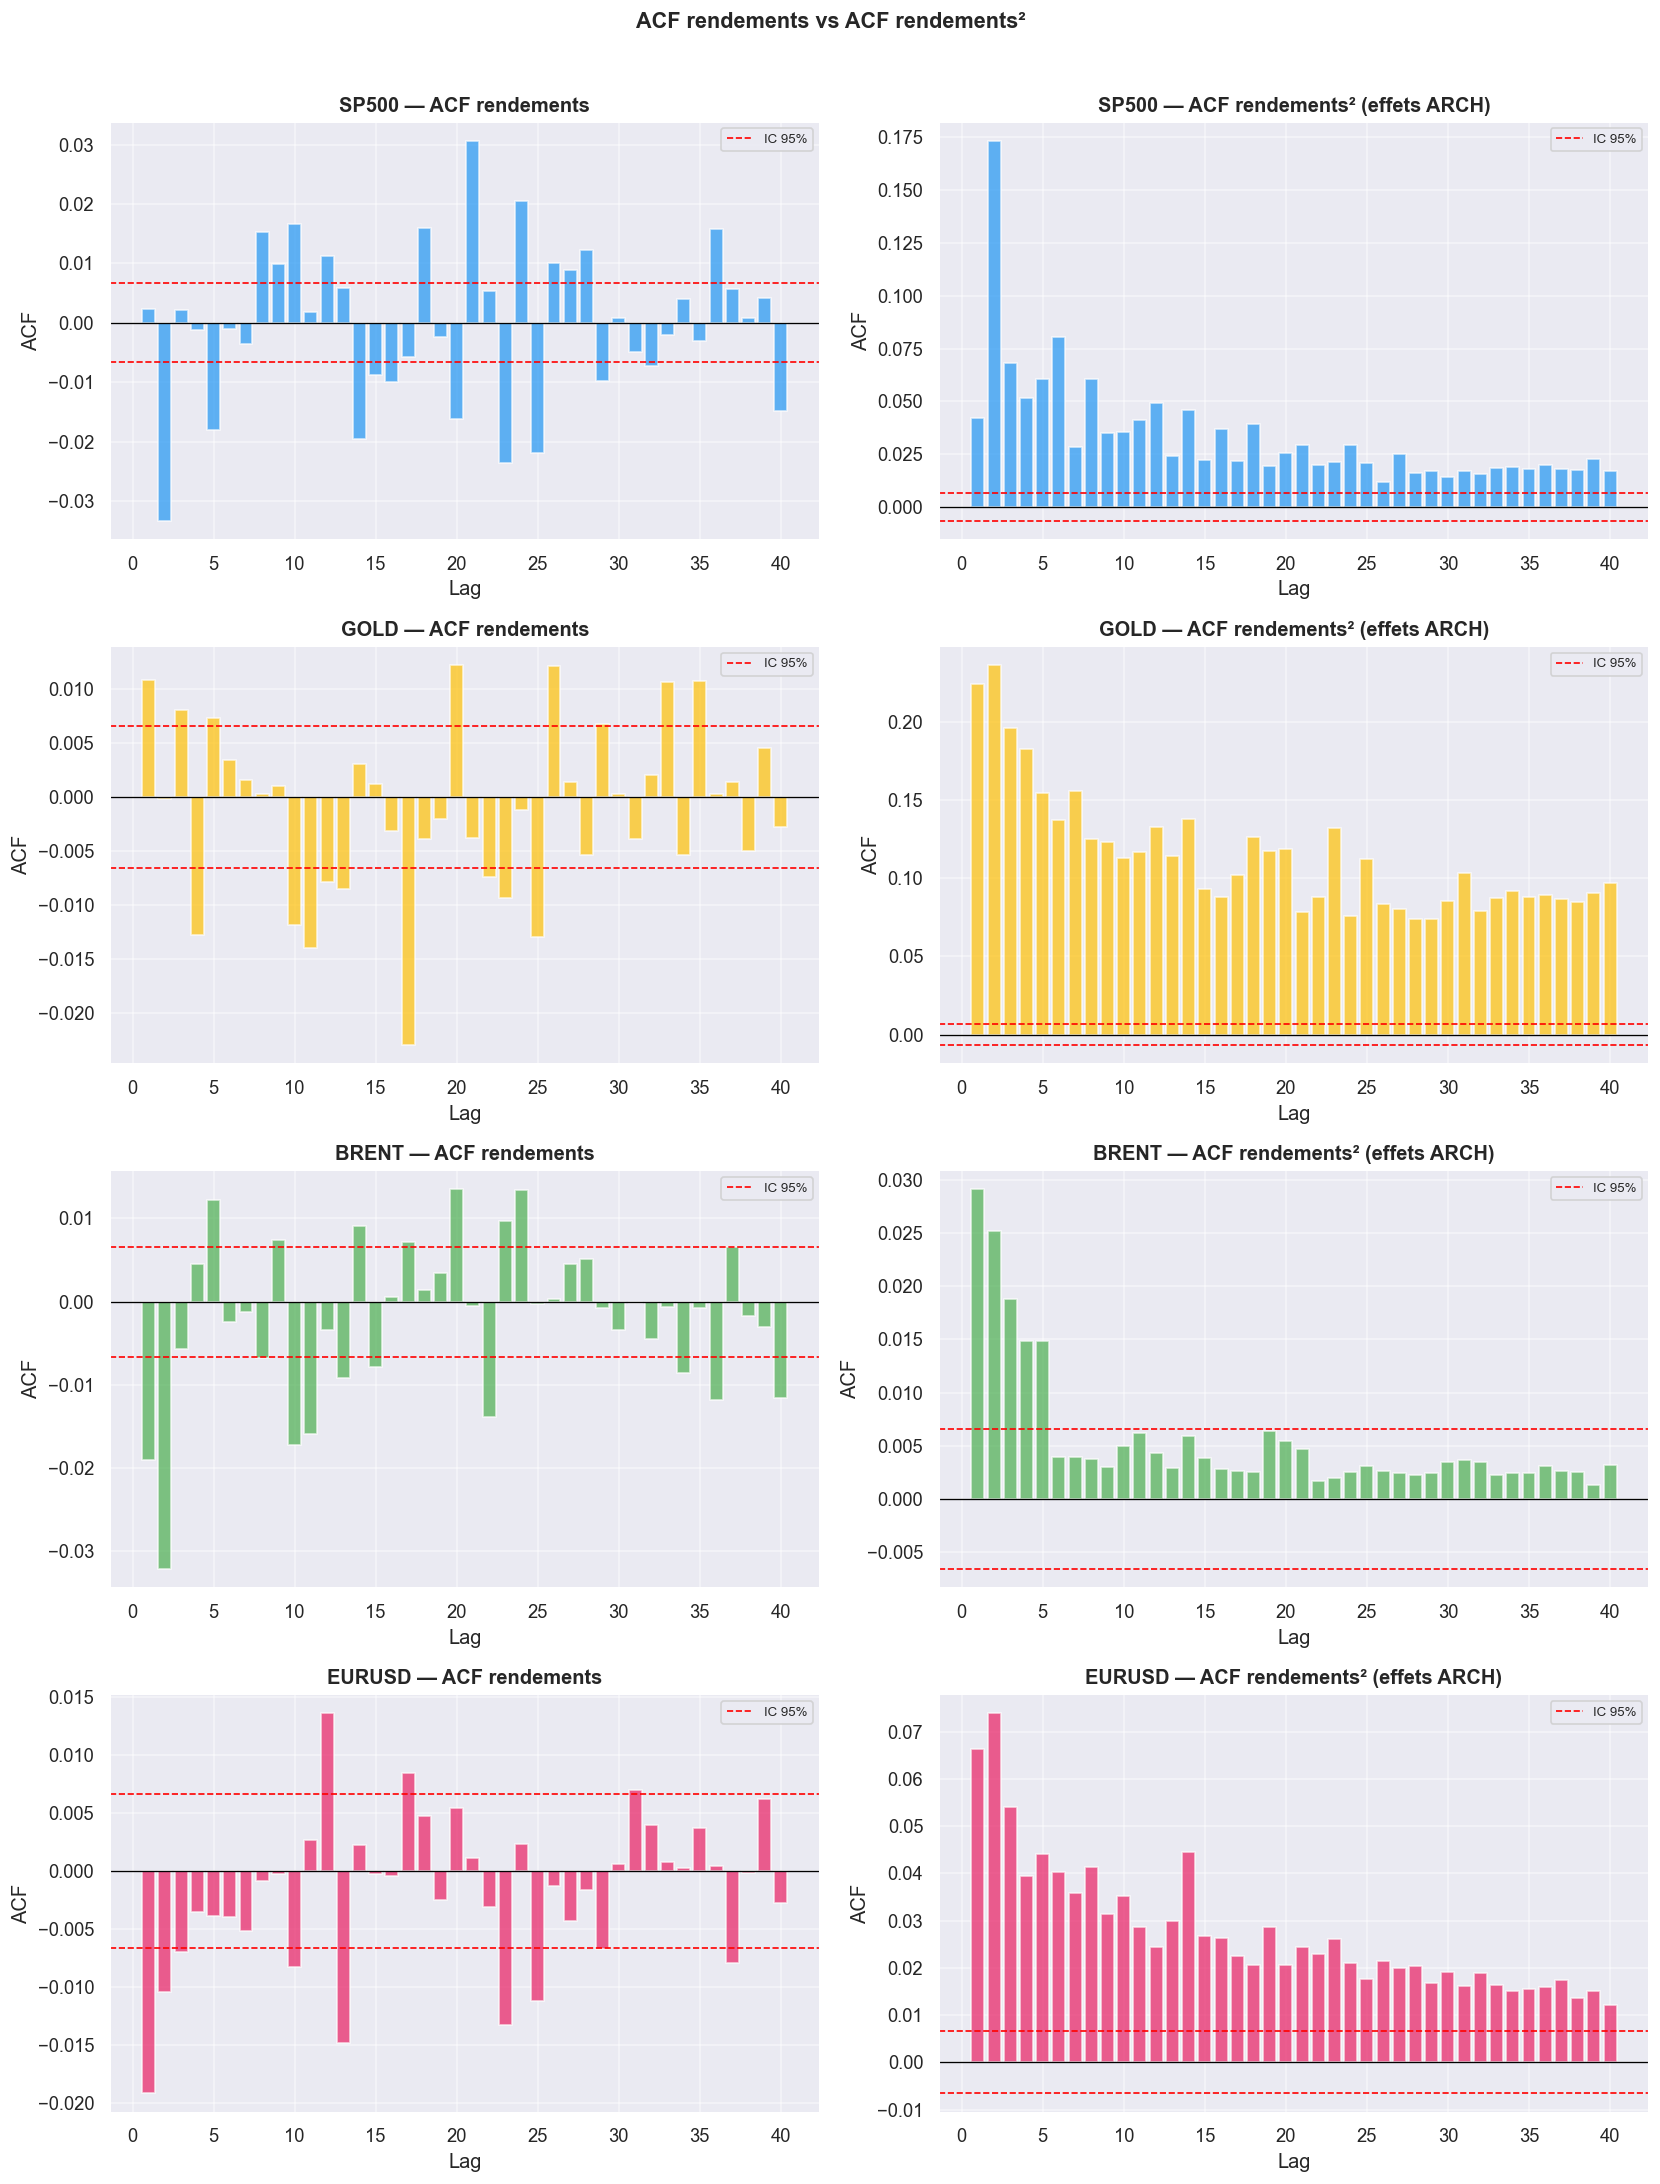

In [15]:
# ── 8.1 ACF des rendements et des rendements² ─────────────────────────────────
NLAGS = 40
conf  = 1.96 / np.sqrt(len(df_returns))

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for i, name in enumerate(df_returns.columns):
    r  = df_returns[name].dropna()
    r2 = r ** 2
    acf_r  = compute_acf(r,  nlags=NLAGS)
    acf_r2 = compute_acf(r2, nlags=NLAGS)
    lags   = np.arange(NLAGS + 1)
    for j, (acf_vals, title) in enumerate([
        (acf_r,  f'{name} — ACF rendements'),
        (acf_r2, f'{name} — ACF rendements² (effets ARCH)')
    ]):
        ax = axes[i, j]
        ax.bar(lags[1:], acf_vals[1:], color=COLORS[name], alpha=0.7)
        ax.axhline(0,      color='black', lw=0.8)
        ax.axhline( conf,  color='red', lw=1, linestyle='--', label='IC 95%')
        ax.axhline(-conf,  color='red', lw=1, linestyle='--')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Lag')
        ax.set_ylabel('ACF')
        ax.legend(fontsize=8)
plt.suptitle('ACF rendements vs ACF rendements²', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# ── 8.2 Test de Ljung-Box ─────────────────────────────────────────────────────
print("=== Test de Ljung-Box (H0 : pas d'autocorrélation) ===")
print(f"{'Actif':8s} {'Série':12s} {'Lag':>5s} {'Stat Q':>10s} {'p-value':>10s} {'Décision':>28s}")
print('-' * 78)
for name in df_returns.columns:
    r  = df_returns[name].dropna()
    r2 = r ** 2
    for lag in [10, 20]:
        q_r,  p_r  = ljung_box(r,  lag)
        q_r2, p_r2 = ljung_box(r2, lag)
        dec_r  = '❌ Autocorrélation'    if p_r  < 0.05 else '✅ Indépendant'
        dec_r2 = '❌ Effet ARCH détecté' if p_r2 < 0.05 else "✅ Pas d'effet ARCH"
        print(f"{name:8s} {'Rendements':12s} {lag:>5d} {q_r:>10.2f} {p_r:>10.4f} {dec_r:>28s}")
        print(f"{name:8s} {'Rendements²':12s} {lag:>5d} {q_r2:>10.2f} {p_r2:>10.4f} {dec_r2:>28s}")
    print()

=== Test de Ljung-Box (H0 : pas d'autocorrélation) ===
Actif    Série          Lag     Stat Q    p-value                     Décision
------------------------------------------------------------------------------
SP500    Rendements      10     182.16     0.0000            ❌ Autocorrélation
SP500    Rendements²     10    4946.14     0.0000         ❌ Effet ARCH détecté
SP500    Rendements      20     294.97     0.0000            ❌ Autocorrélation
SP500    Rendements²     20    5975.09     0.0000         ❌ Effet ARCH détecté

GOLD     Rendements      10      48.67     0.0000            ❌ Autocorrélation
GOLD     Rendements²     10   25332.41     0.0000         ❌ Effet ARCH détecté
GOLD     Rendements      20     140.57     0.0000            ❌ Autocorrélation
GOLD     Rendements²     20   37103.62     0.0000         ❌ Effet ARCH détecté

BRENT    Rendements      10     176.39     0.0000            ❌ Autocorrélation
BRENT    Rendements²     10     207.62     0.0000         ❌ Effet ARCH dét

---
## 9. Analyse de la Volatilité

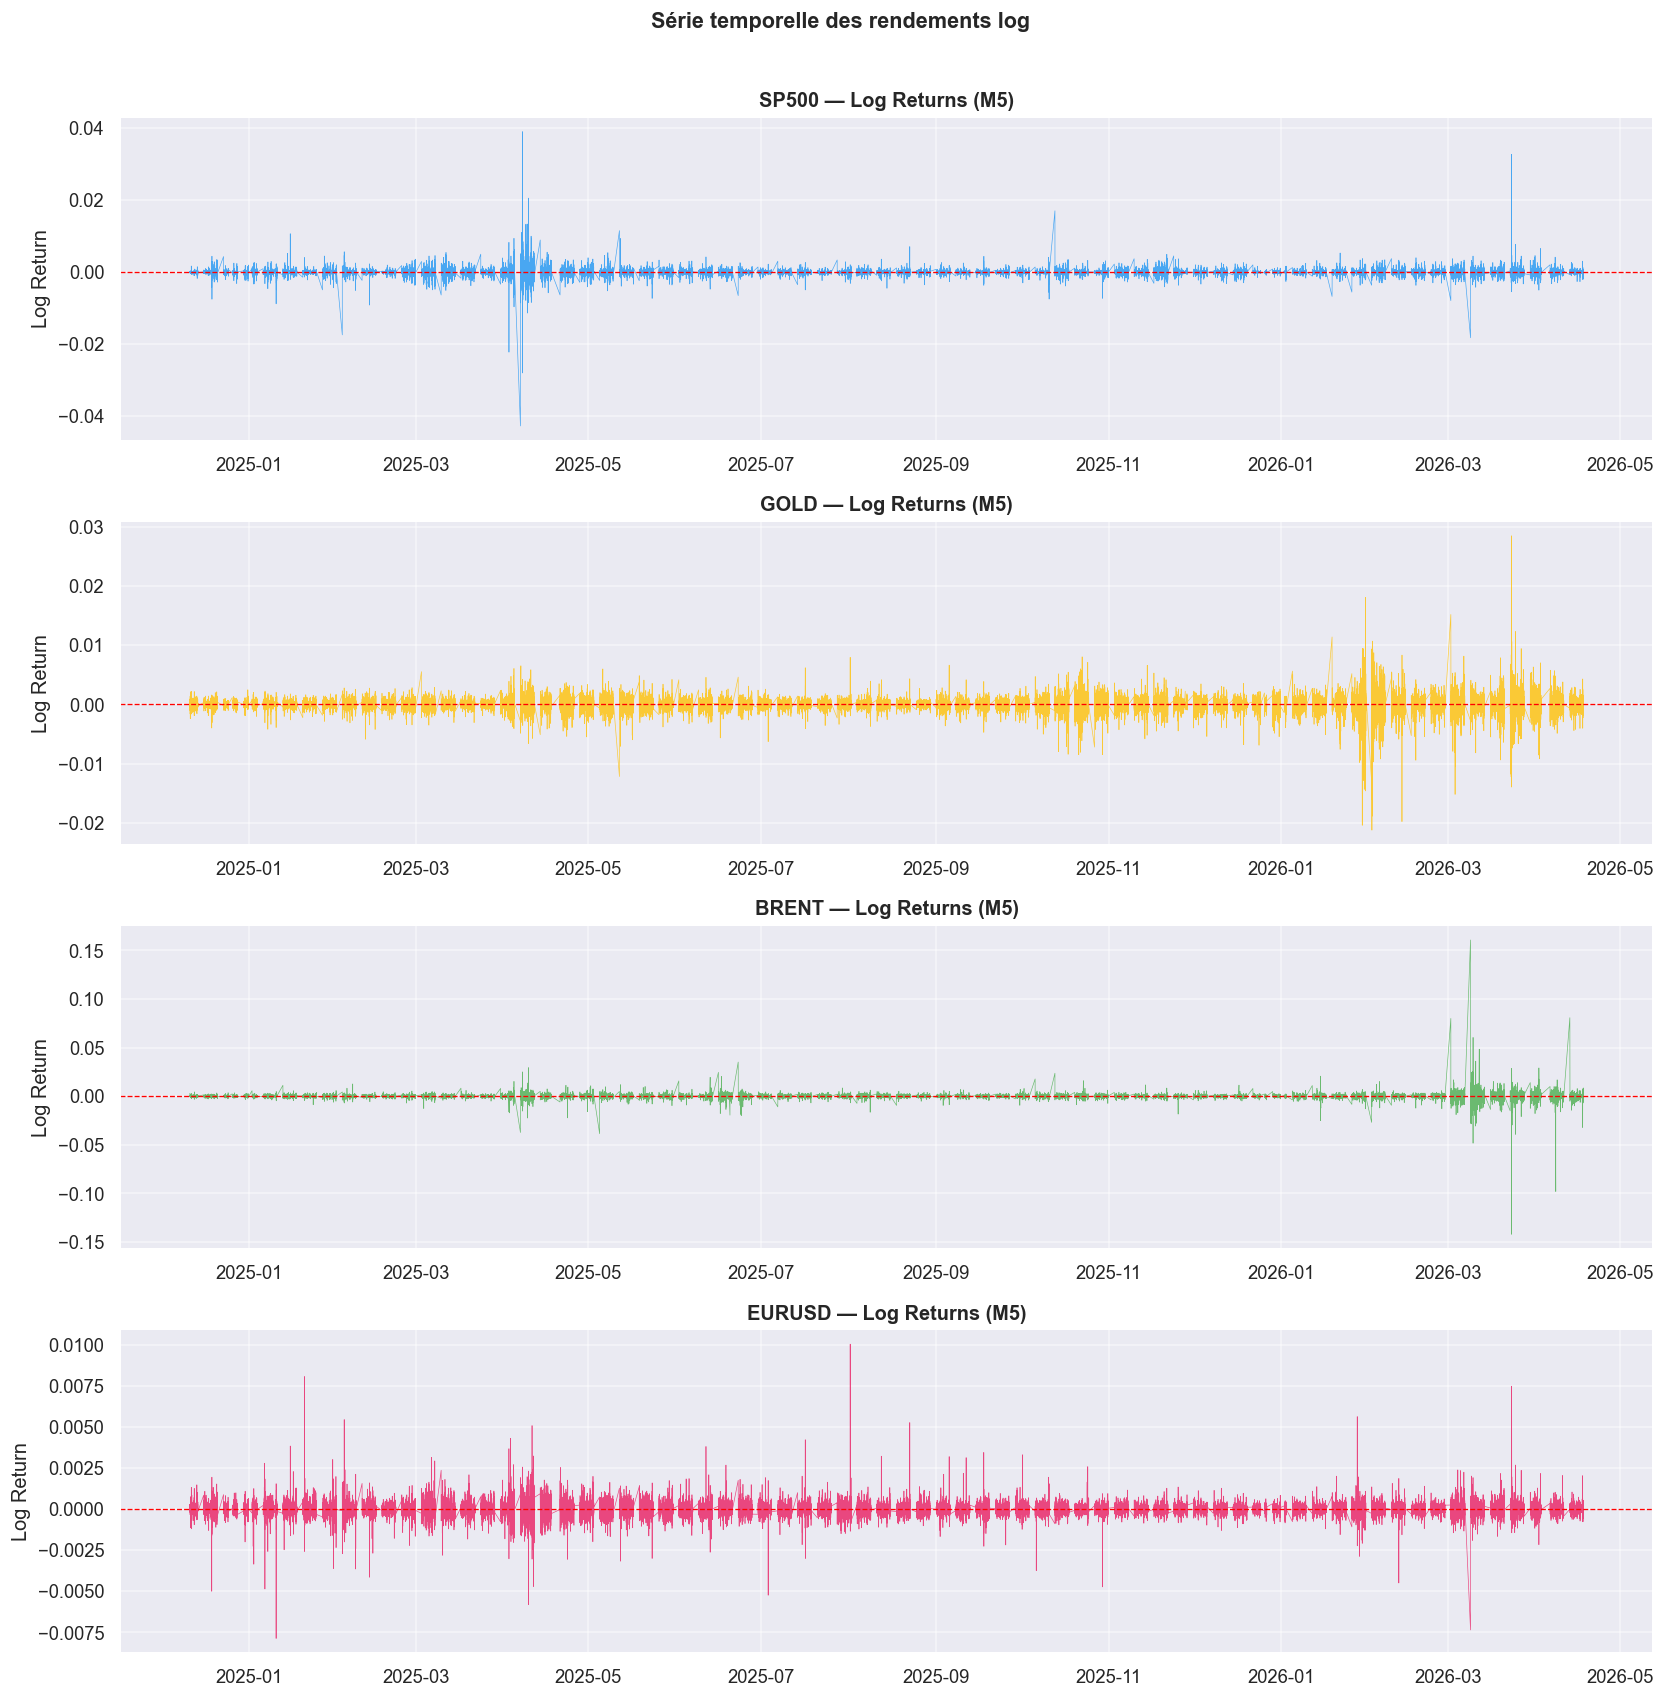

In [17]:
# ── 9.1 Série temporelle des rendements ───────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, name in zip(axes, df_returns.columns):
    ax.plot(df_returns[name], lw=0.4, color=COLORS[name], alpha=0.8)
    ax.axhline(0, color='red', lw=0.8, linestyle='--')
    ax.set_title(f'{name} — Log Returns (M5)', fontweight='bold')
    ax.set_ylabel('Log Return')
plt.suptitle('Série temporelle des rendements log', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

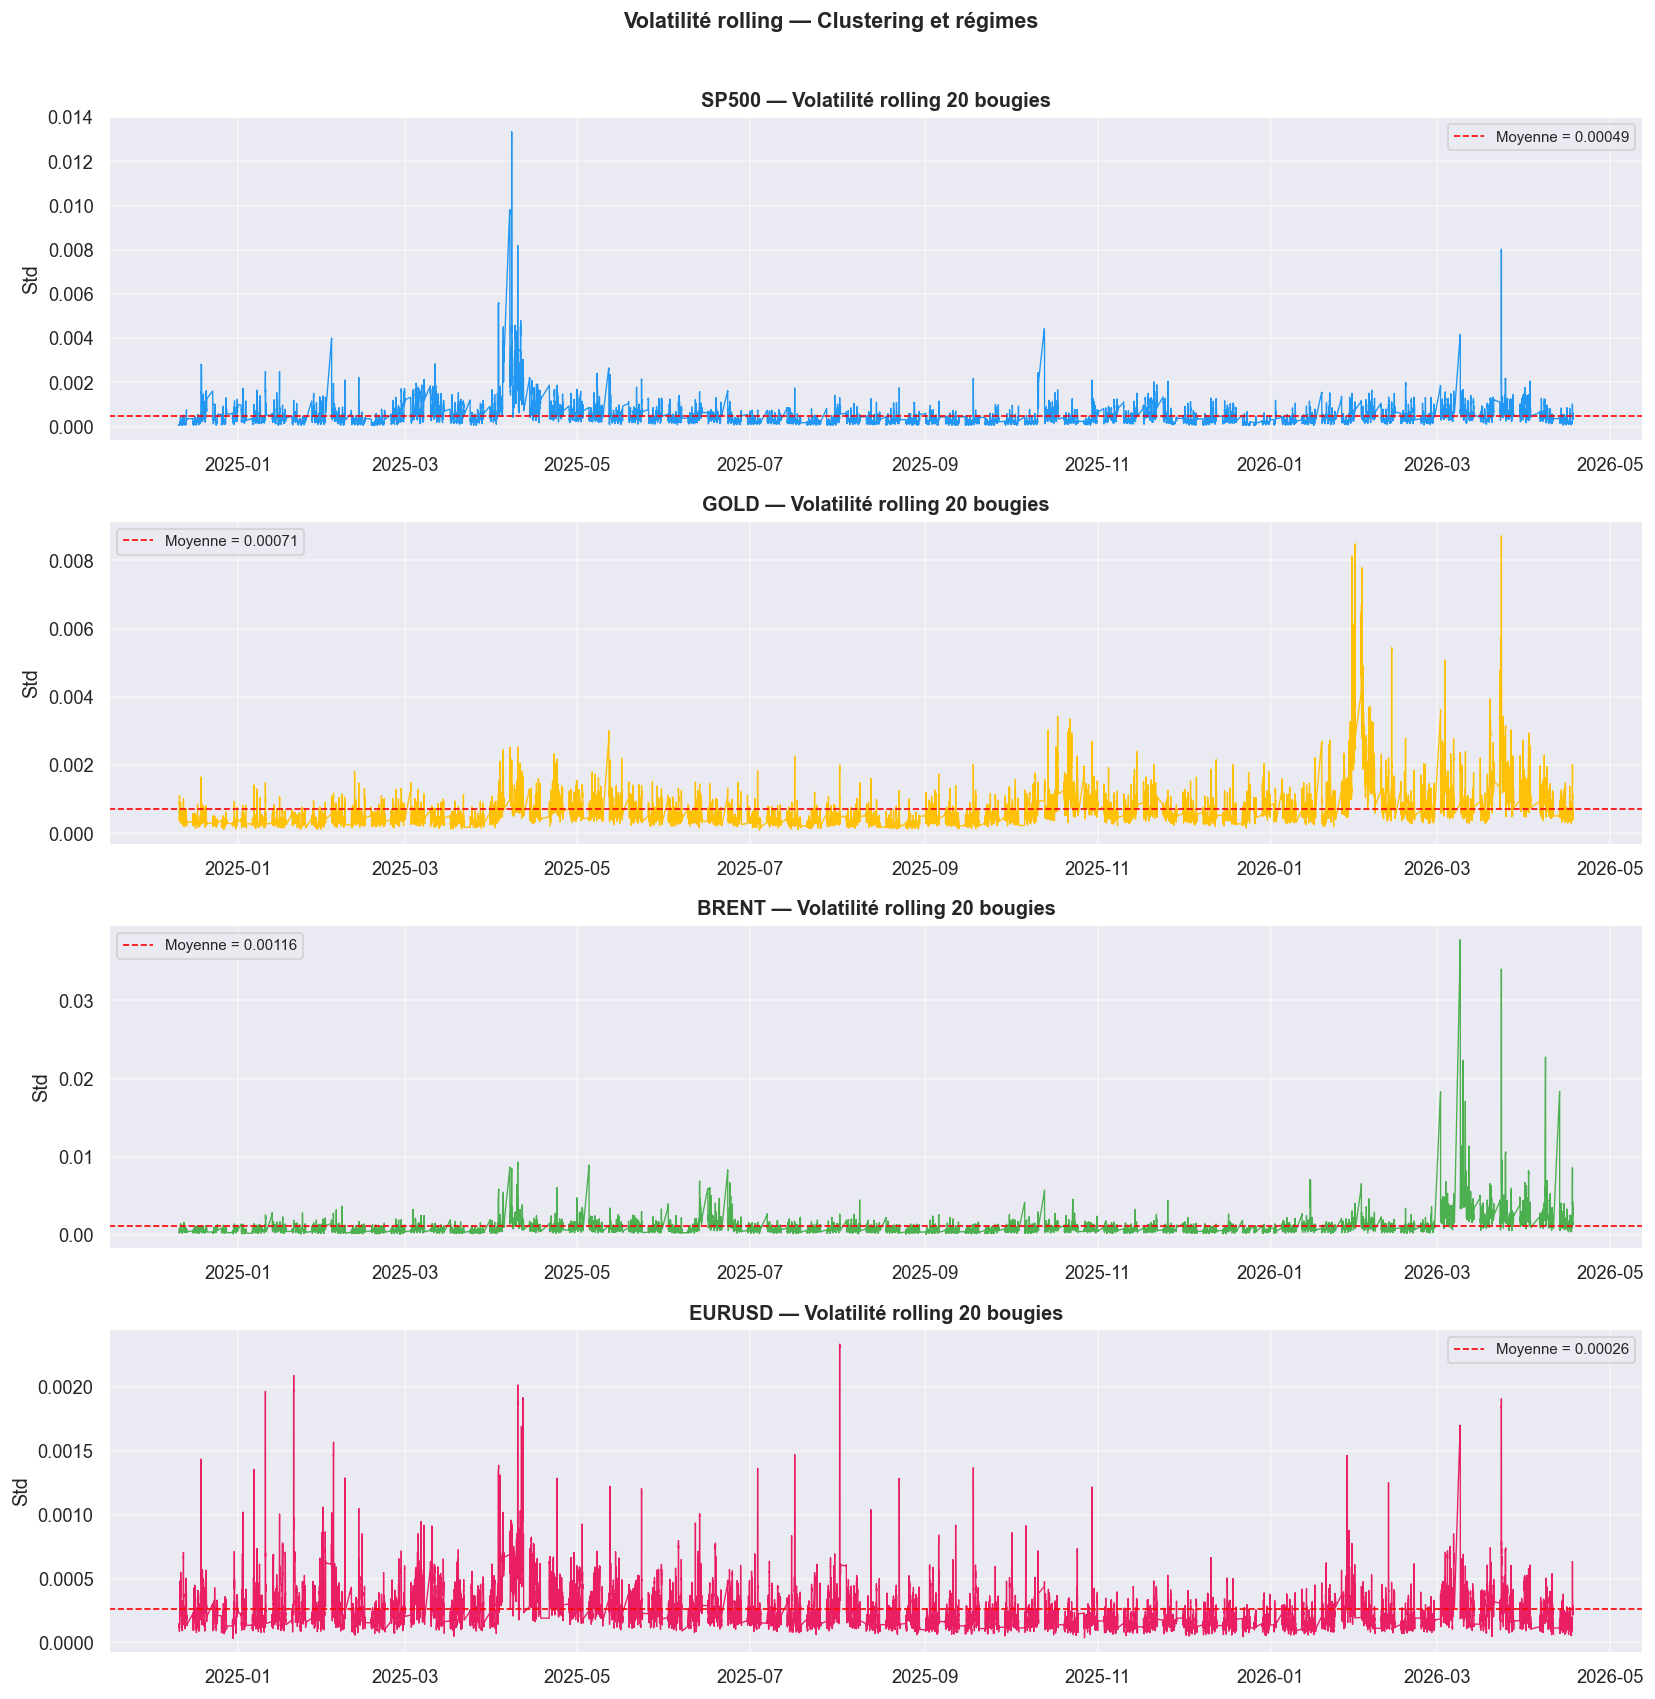

In [18]:
# ── 9.2 Volatilité rolling 20 bougies ─────────────────────────────────────────
WINDOW = 20
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
for ax, name in zip(axes, df_returns.columns):
    vol = df_returns[name].rolling(WINDOW).std()
    ax.plot(vol, lw=0.8, color=COLORS[name])
    ax.axhline(vol.mean(), color='red', lw=1, linestyle='--', label=f'Moyenne = {vol.mean():.5f}')
    ax.set_title(f'{name} — Volatilité rolling {WINDOW} bougies', fontweight='bold')
    ax.set_ylabel('Std')
    ax.legend(fontsize=9)
plt.suptitle('Volatilité rolling — Clustering et régimes', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

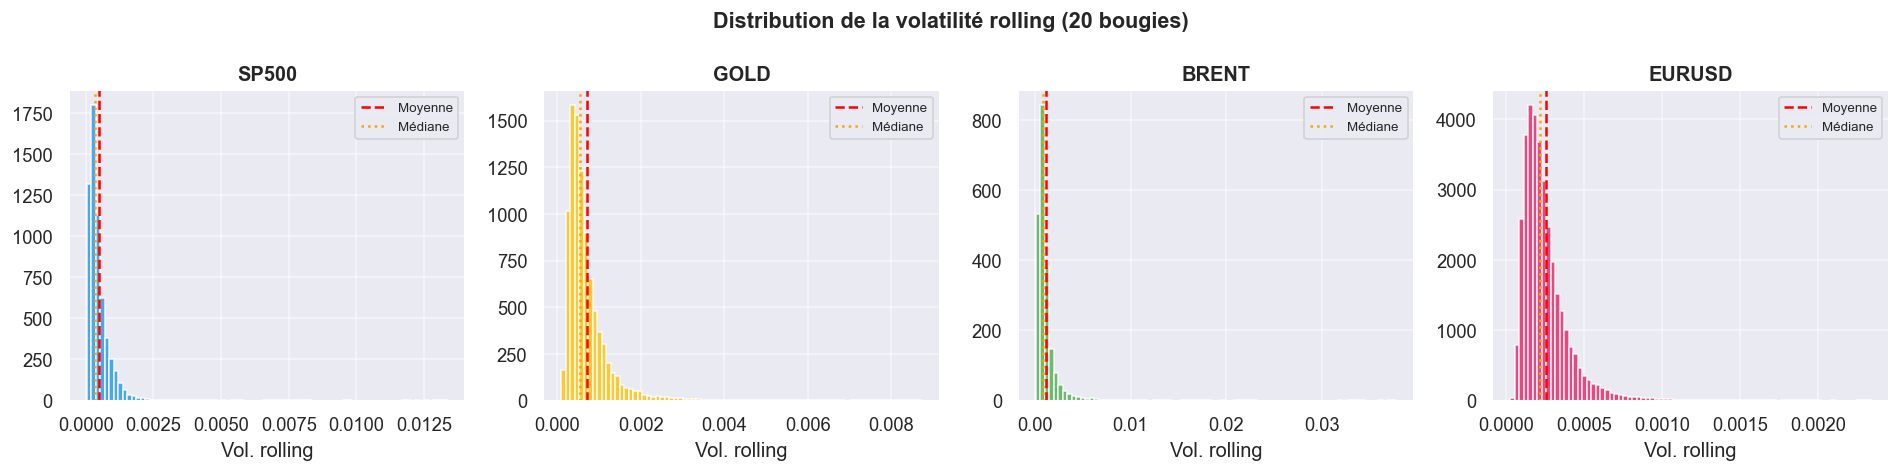

In [19]:
# ── 9.3 Distribution de la volatilité rolling ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, name in zip(axes, df_returns.columns):
    vol = df_returns[name].rolling(WINDOW).std().dropna()
    ax.hist(vol, bins=80, density=True, color=COLORS[name], alpha=0.8)
    ax.axvline(vol.mean(),   color='red',    lw=1.5, linestyle='--', label='Moyenne')
    ax.axvline(vol.median(), color='orange', lw=1.5, linestyle=':',  label='Médiane')
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Vol. rolling')
    ax.legend(fontsize=8)
plt.suptitle('Distribution de la volatilité rolling (20 bougies)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

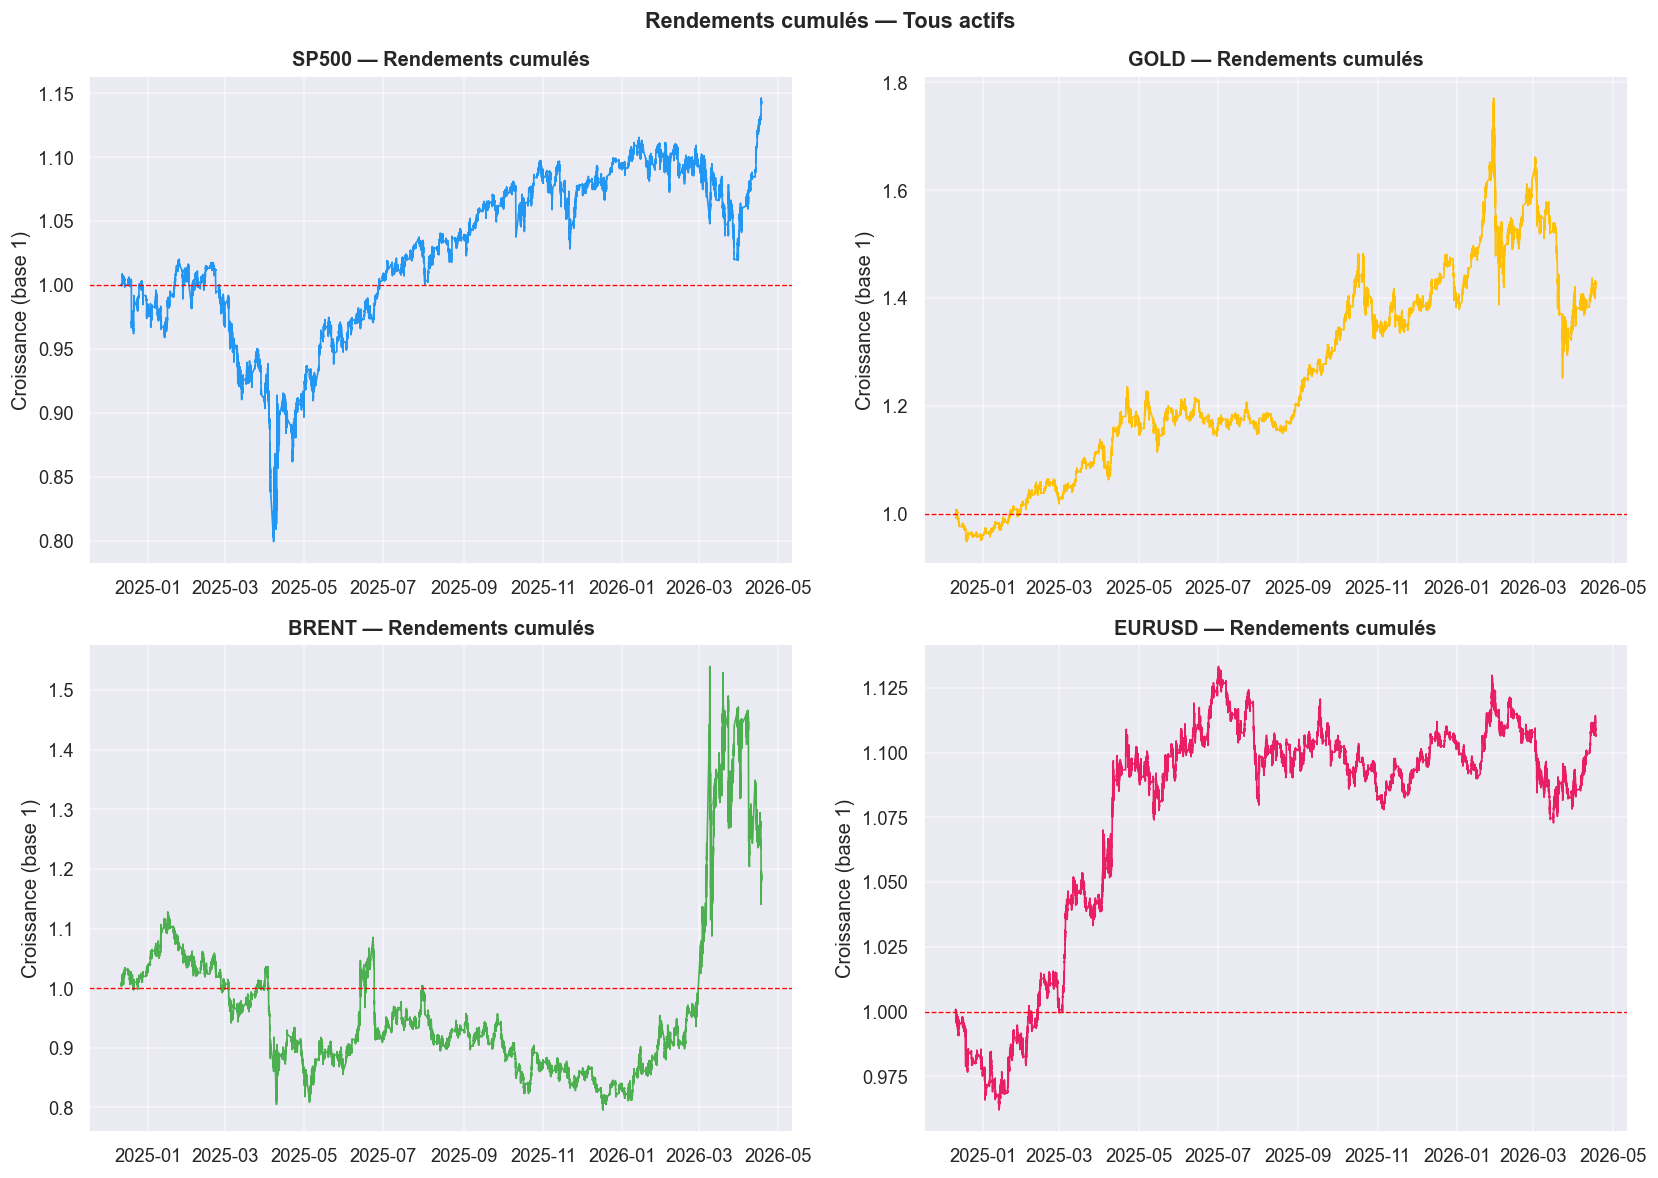

In [20]:
# ── 9.4 Rendements cumulés ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    cum = np.exp(df_returns[name].dropna().cumsum())
    ax.plot(cum, lw=1, color=COLORS[name])
    ax.axhline(1, color='red', lw=0.8, linestyle='--')
    ax.set_title(f'{name} — Rendements cumulés', fontweight='bold')
    ax.set_ylabel('Croissance (base 1)')
plt.suptitle('Rendements cumulés — Tous actifs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Tail Risk — VaR et CVaR

In [21]:
# ── 10.1 Tableau VaR / CVaR ───────────────────────────────────────────────────
risk_rows = []
for name in df_returns.columns:
    r   = df_returns[name].dropna()
    row = {'Actif': name}
    for alpha in [0.05, 0.01]:
        var  = r.quantile(alpha)
        cvar = r[r <= var].mean()
        conf = int((1 - alpha) * 100)
        row[f'VaR {conf}%']  = round(var,  6)
        row[f'CVaR {conf}%'] = round(cvar, 6)
    risk_rows.append(row)
display(pd.DataFrame(risk_rows).set_index('Actif'))

,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
Actif,,,,
SP500,-0.000858,-0.001607,-0.001977,-0.003122
GOLD,-0.001186,-0.002178,-0.002633,-0.004259
BRENT,-0.001856,-0.003602,-0.004173,-0.007597
EURUSD,-0.000433,-0.000688,-0.000797,-0.001198


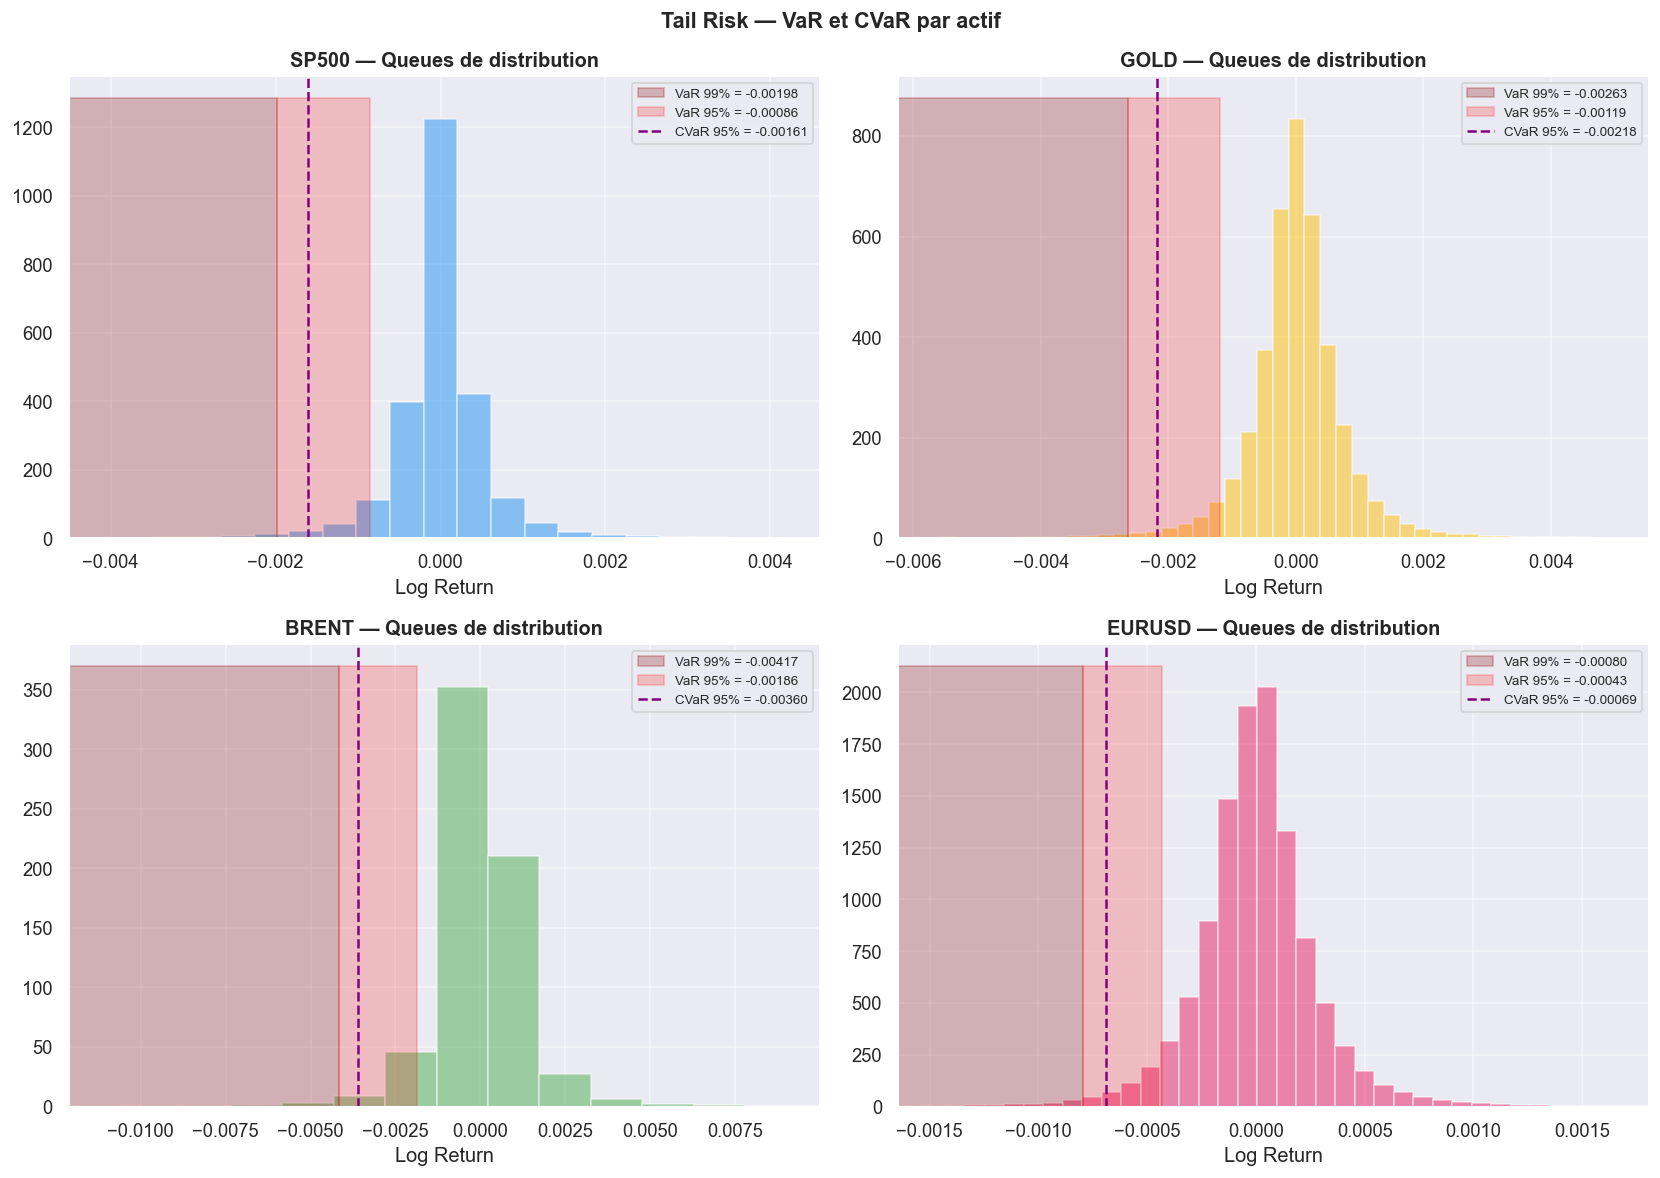

In [22]:
# ── 10.2 Visualisation des queues ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for ax, name in zip(axes, df_returns.columns):
    r      = df_returns[name].dropna()
    var95  = r.quantile(0.05)
    var99  = r.quantile(0.01)
    cvar95 = r[r <= var95].mean()
    ax.hist(r, bins=200, density=True, color=COLORS[name], alpha=0.5)
    ymax = ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1
    ax.fill_betweenx([0, ymax], r.min(), var99, alpha=0.25, color='darkred', label=f'VaR 99% = {var99:.5f}')
    ax.fill_betweenx([0, ymax], var99, var95,   alpha=0.20, color='red',     label=f'VaR 95% = {var95:.5f}')
    ax.axvline(cvar95, color='purple', lw=1.5, linestyle='--', label=f'CVaR 95% = {cvar95:.5f}')
    ax.set_xlim(r.quantile(0.001), r.quantile(0.999))
    ax.set_title(f'{name} — Queues de distribution', fontweight='bold')
    ax.set_xlabel('Log Return')
    ax.legend(fontsize=8)
plt.suptitle('Tail Risk — VaR et CVaR par actif', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 11. Corrélations

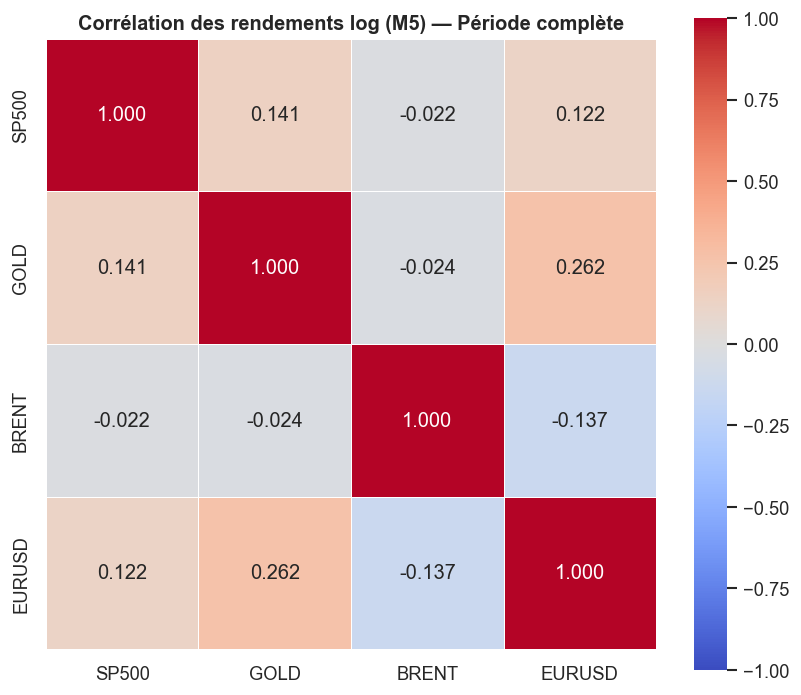

In [23]:
# ── 11.1 Heatmap statique ─────────────────────────────────────────────────────
plt.figure(figsize=(7, 6))
sns.heatmap(
    df_returns.corr(), annot=True, fmt='.3f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, vmin=-1, vmax=1
)
plt.title('Corrélation des rendements log (M5) — Période complète', fontweight='bold')
plt.tight_layout()
plt.show()

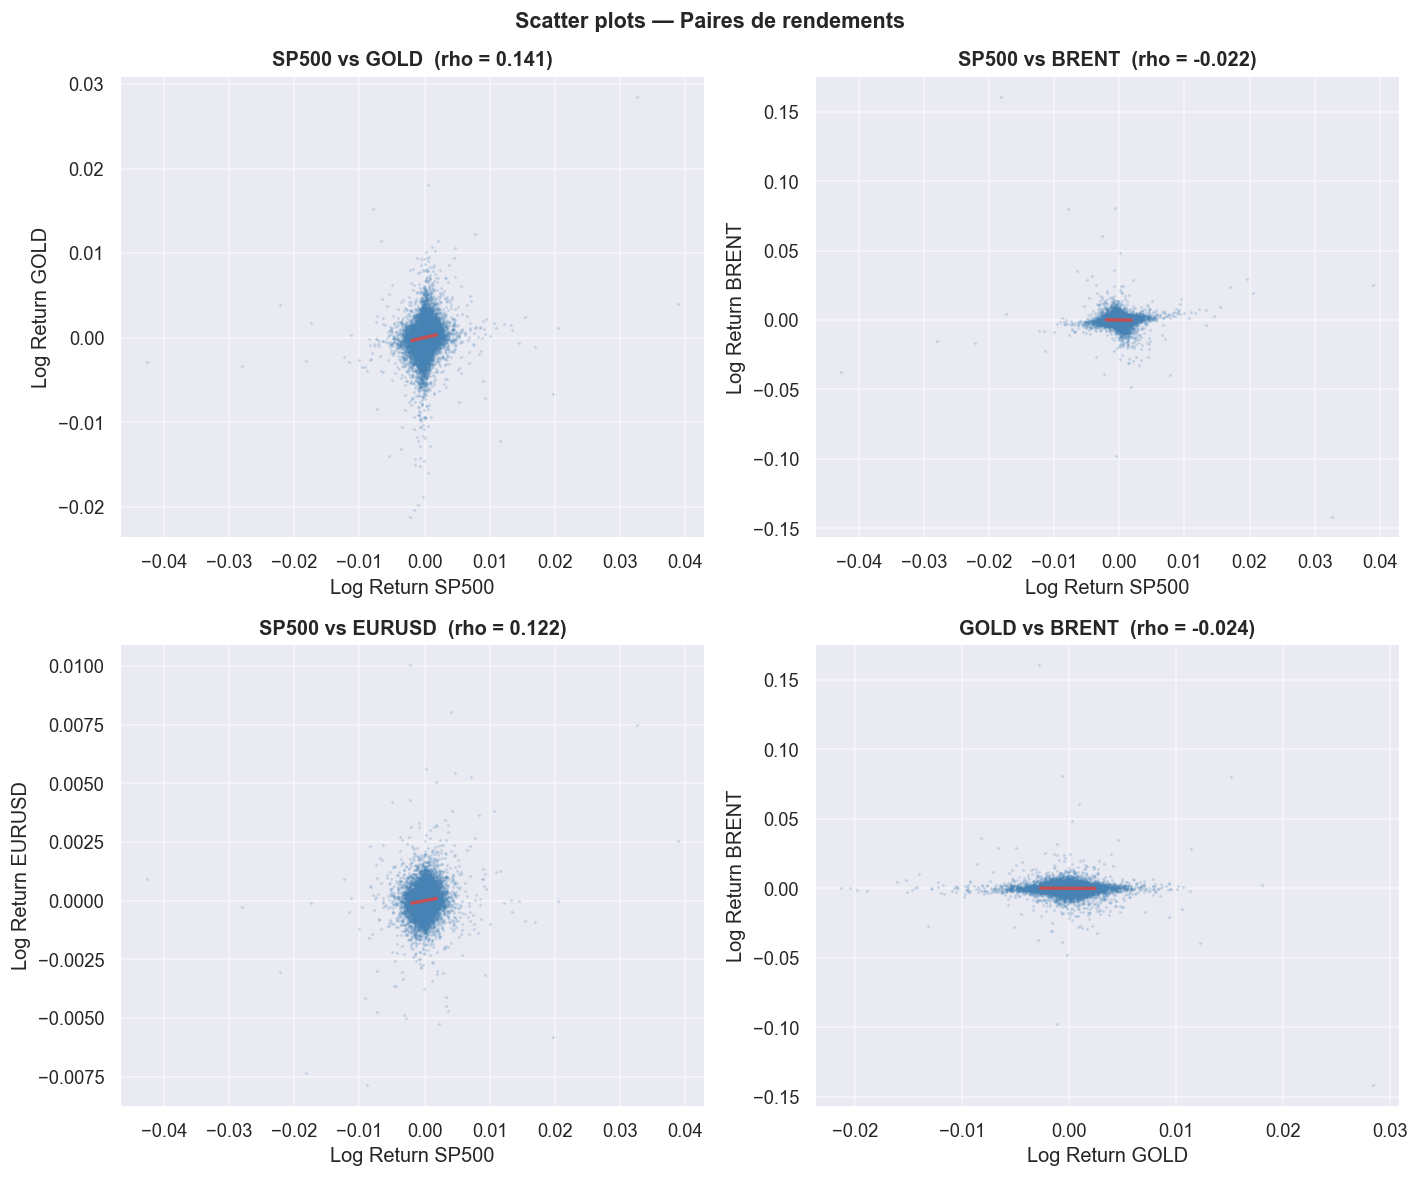

In [24]:
# ── 11.2 Scatter plots par paire ──────────────────────────────────────────────
pairs = [('SP500', 'GOLD'), ('SP500', 'BRENT'), ('SP500', 'EURUSD'), ('GOLD', 'BRENT')]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for ax, (a, b) in zip(axes, pairs):
    x   = df_returns[a].dropna()
    y   = df_returns[b].reindex(x.index).dropna()
    x   = x.reindex(y.index)
    rho = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=1, alpha=0.15, color='steelblue')
    m, b_ = np.polyfit(x, y, 1)
    xfit  = np.linspace(x.quantile(0.01), x.quantile(0.99), 200)
    ax.plot(xfit, m * xfit + b_, 'r-', lw=2)
    ax.set_title(f'{a} vs {b}  (rho = {rho:.3f})', fontweight='bold')
    ax.set_xlabel(f'Log Return {a}')
    ax.set_ylabel(f'Log Return {b}')
plt.suptitle('Scatter plots — Paires de rendements', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

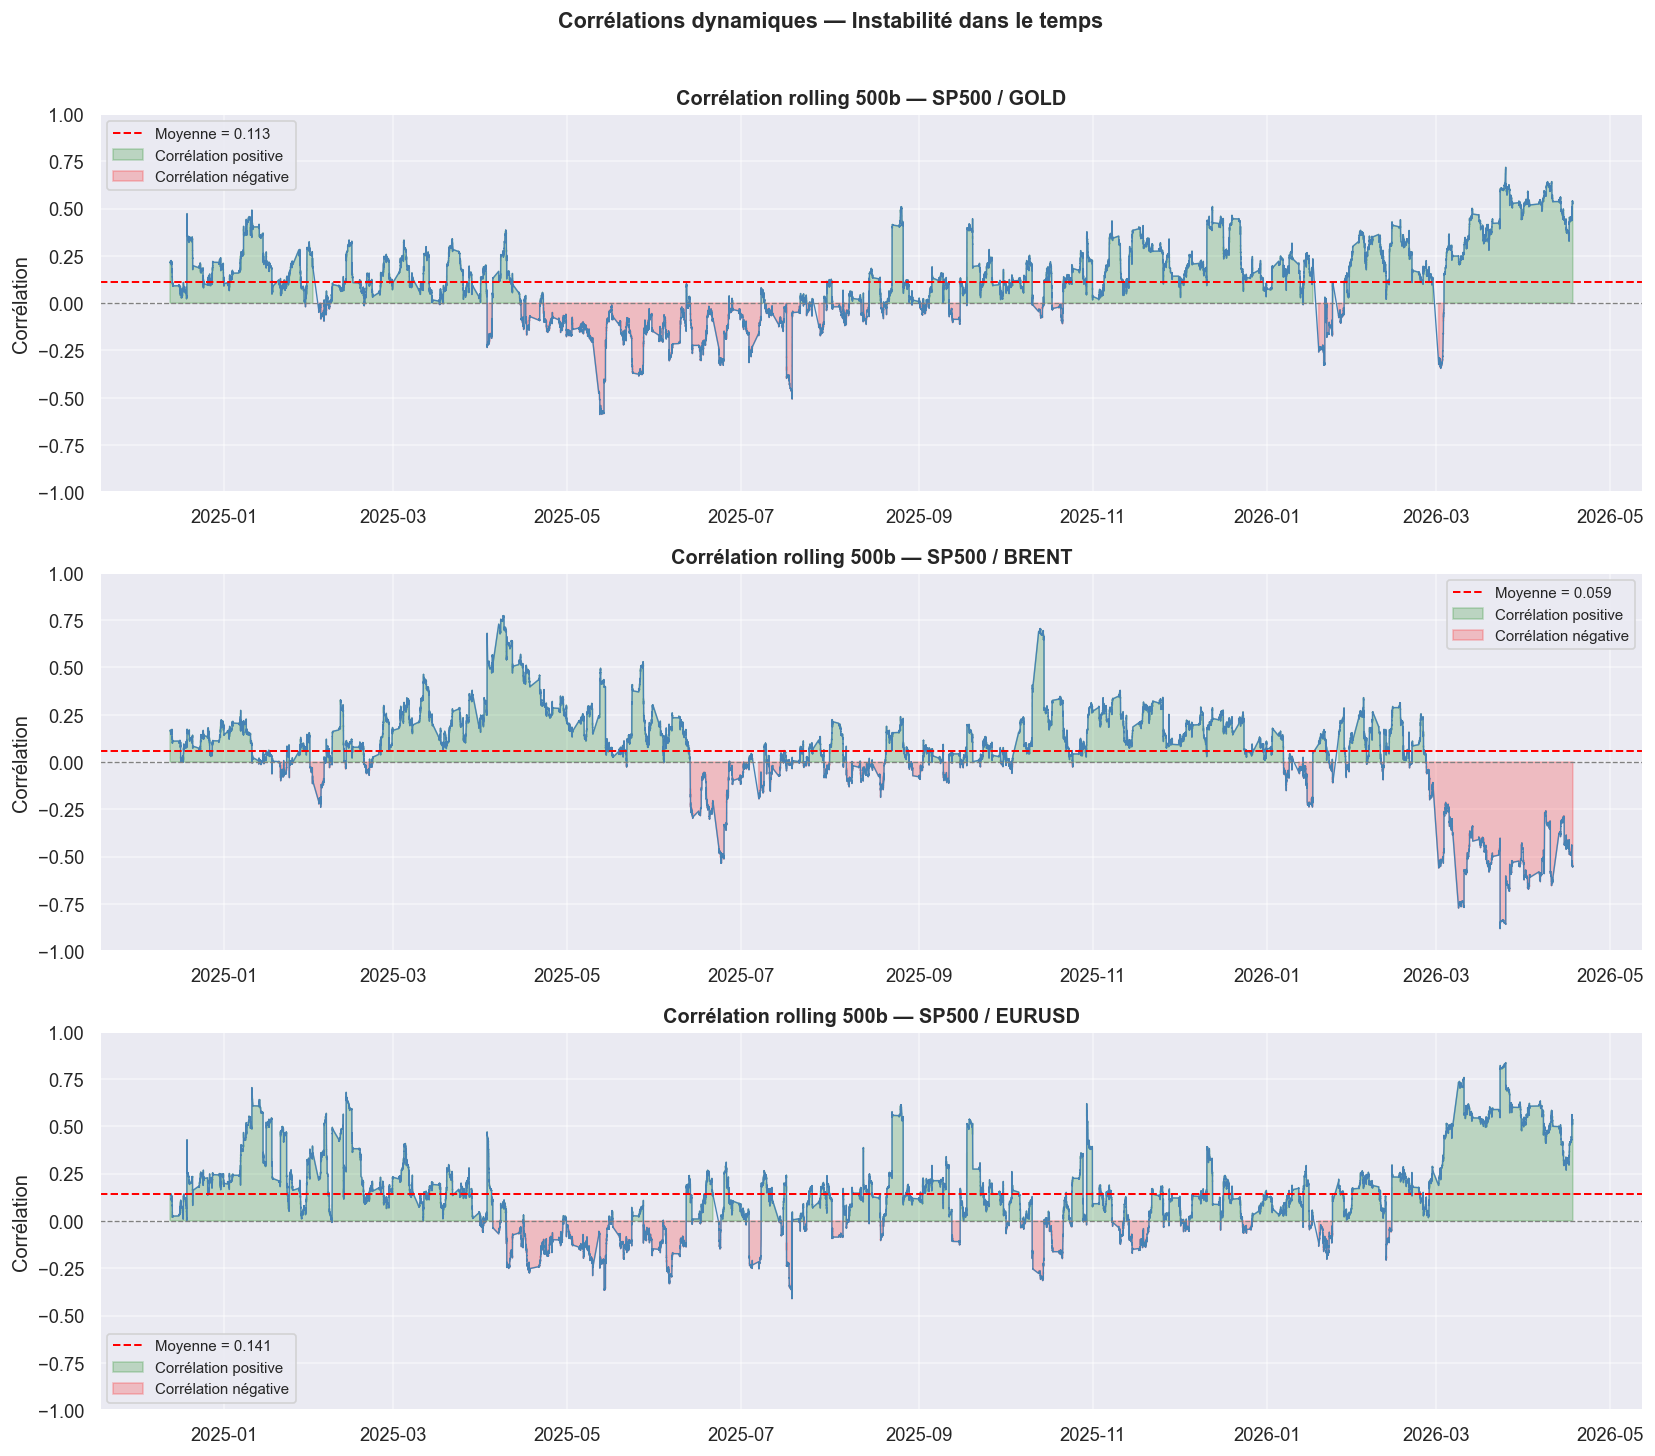

In [25]:
# ── 11.3 Corrélation rolling dynamique ────────────────────────────────────────
ROLL = 500
pairs_roll = [('SP500', 'GOLD'), ('SP500', 'BRENT'), ('SP500', 'EURUSD')]
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for ax, (a, b) in zip(axes, pairs_roll):
    rc = df_returns[a].rolling(ROLL).corr(df_returns[b])
    ax.plot(rc, lw=0.8, color='steelblue')
    ax.axhline(0,         color='gray', lw=0.8, linestyle='--')
    ax.axhline(rc.mean(), color='red',  lw=1.2, linestyle='--', label=f'Moyenne = {rc.mean():.3f}')
    ax.fill_between(rc.index, 0, rc, where=(rc >= 0), alpha=0.2, color='green', label='Corrélation positive')
    ax.fill_between(rc.index, 0, rc, where=(rc  < 0), alpha=0.2, color='red',   label='Corrélation négative')
    ax.set_title(f'Corrélation rolling {ROLL}b — {a} / {b}', fontweight='bold')
    ax.set_ylabel('Corrélation')
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=9)
plt.suptitle('Corrélations dynamiques — Instabilité dans le temps', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 12. Tableau de synthèse complet

In [26]:
synthese_rows = []
for name in df_returns.columns:
    r            = df_returns[name].dropna()
    jb, jb_p     = jarque_bera(r)
    adf_s, adf_p, _ = adf_test(r)
    _, lb_p      = ljung_box(r,    20)
    _, lb2_p     = ljung_box(r**2, 20)
    var95        = r.quantile(0.05)
    cvar95       = r[r <= var95].mean()
    synthese_rows.append({
        'Actif':          name,
        'N bougies':      len(r),
        'Moyenne':        round(r.mean(), 7),
        'Std':            round(r.std(), 6),
        'Skewness':       round(r.skew(), 4),
        'Kurtosis exc.':  round(r.kurtosis(), 4),
        'Vol. Ann. (%)':  round(r.std() * np.sqrt(BOUGIES_PAR_AN) * 100, 2),
        'JB p-value':     round(jb_p, 4),
        'Normale ?':      '❌ Non' if jb_p < 0.05 else '✅ Oui',
        'ADF p-value':    round(adf_p, 4),
        'Stationnaire ?': '✅ Oui' if adf_p < 0.05 else '❌ Non',
        'LB p (ret)':     round(lb_p, 4),
        'LB p (ret²)':    round(lb2_p, 4),
        'Effet ARCH ?':   '✅ Oui' if lb2_p < 0.05 else '❌ Non',
        'VaR 95%':        round(var95, 6),
        'CVaR 95%':       round(cvar95, 6),
    })
synthese_df = pd.DataFrame(synthese_rows).set_index('Actif')
print('=== TABLEAU DE SYNTHÈSE COMPLET ===')
display(synthese_df.T)

=== TABLEAU DE SYNTHÈSE COMPLET ===


Actif,SP500,GOLD,BRENT,EURUSD
N bougies,87990,87990,87990,87990
Moyenne,0.000002,0.000004,0.000002,0.000001
Std,0.000716,0.00091,0.001789,0.000307
Skewness,0.1884,-0.8237,2.5342,0.4252
Kurtosis exc.,385.5714,48.4013,1447.12,51.7327
Vol. Ann. (%),10.03,12.75,25.08,4.31
JB p-value,0.0,0.0,0.0,0.0
Normale ?,❌ Non,❌ Non,❌ Non,❌ Non
ADF p-value,0.01,0.01,0.01,0.01
Stationnaire ?,✅ Oui,✅ Oui,✅ Oui,✅ Oui


---
## 13. Conclusions

| Propriété | Résultat attendu | Implication pour la modélisation |
|---|---|---|
| **Non-normalité** | Kurtosis très élevée, queues épaisses | Les modèles gaussiens sous-estiment le risque extrême |
| **Stationnarité** | Prix non-stationnaires, rendements stationnaires | Travailler en log returns, pas en prix |
| **Autocorrélation** | Faible sur les rendements, forte sur les rendements² | Présence d'effets ARCH (volatility clustering) |
| **Corrélations** | Variables et instables dans le temps | Les corrélations statiques sont trompeuses |
| **Tail Risk** | VaR/CVaR significatives | Indispensable de les intégrer dans la gestion du risque |

Ces résultats sont cohérents avec la littérature financière (Fama, 1965 ; Mandelbrot, 1963) :
- Les rendements M5 présentent des **queues épaisses** (leptokurtose), confirmant l'inadéquation de la loi normale.
- Le **volatility clustering** (effets ARCH) justifie l'usage de modèles conditionnels (GARCH, modèles à régimes).
- Les **corrélations dynamiques** soulignent l'intérêt d'un modèle prenant en compte les régimes de marché.